In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("="*80)
print("EXPLORATION DES VALEURS UNIQUES - MÉTIERS")
print("="*80)

# 1. Chargement des données
df_metiers = pd.read_csv('../data/processed/metiers_extraits.csv')
df_metier_ref = pd.read_csv('../data/raw/metier.csv')

print(f"✅ metiers_extraits.csv : {df_metiers.shape[0]} lignes")
print(f"✅ metier.csv : {df_metier_ref.shape[0]} lignes")

# ============================================================================
# 1. ANALYSE DE metier.csv (référence)
# ============================================================================

print("\n" + "="*80)
print("📋 ANALYSE DE metier.csv (SOURCE DE RÉFÉRENCE)")
print("="*80)

print("\n📌 Structure de metier.csv :")
print(df_metier_ref.info())

print("\n📌 Aperçu des métiers de référence :")
print(df_metier_ref[['secteur', 'metier', 'salaire_moyen_ariary']].head(20))

print(f"\n📌 Statistiques :")
print(f"  - Nombre total de métiers : {len(df_metier_ref)}")
print(f"  - Nombre de secteurs : {df_metier_ref['secteur'].nunique()}")
print(f"  - Salaires - Min : {df_metier_ref['salaire_moyen_ariary'].min():,.0f}")
print(f"  - Salaires - Max : {df_metier_ref['salaire_moyen_ariary'].max():,.0f}")
print(f"  - Salaires - Moyen : {df_metier_ref['salaire_moyen_ariary'].mean():,.0f}")

# Liste complète des métiers de référence
print("\n📋 LISTE COMPLÈTE DES MÉTIERS DE RÉFÉRENCE :")
print("-"*60)
for i, row in df_metier_ref.iterrows():
    print(f"{i+1:>3}. {row['metier']:<40} ({row['secteur']})")

# ============================================================================
# 2. ANALYSE DE q4a_18 (métier principal)
# ============================================================================

print("\n" + "="*80)
print("📋 ANALYSE DE q4a_18 (MÉTIER PRINCIPAL)")
print("="*80)

# Récupérer toutes les valeurs uniques non-nulles
q4a_18_vals = df_metiers['q4a_18'].dropna().unique()
q4a_18_vals = [str(v).strip() for v in q4a_18_vals if str(v).strip() != '']

print(f"\n📌 Statistiques :")
print(f"  - Nombre total de valeurs uniques : {len(q4a_18_vals)}")
print(f"  - Pourcentage de remplissage : {df_metiers['q4a_18'].notna().sum() / len(df_metiers) * 100:.1f}%")

print(f"\n📋 PREMIÈRES 50 VALEURS UNIQUES :")
print("-"*60)
for i, val in enumerate(sorted(q4a_18_vals)[:50], 1):
    print(f"{i:>3}. {val}")

print(f"\n📋 DERNIÈRES 50 VALEURS UNIQUES :")
print("-"*60)
for i, val in enumerate(sorted(q4a_18_vals)[-50:], len(q4a_18_vals)-49):
    print(f"{i:>3}. {val}")

# ============================================================================
# 3. ANALYSE DE q4a_541 (métier secondaire)
# ============================================================================

print("\n" + "="*80)
print("📋 ANALYSE DE q4a_541 (MÉTIER SECONDAIRE)")
print("="*80)

# Récupérer toutes les valeurs uniques non-nulles
q4a_541_vals = df_metiers['q4a_541'].dropna().unique()
q4a_541_vals = [str(v).strip() for v in q4a_541_vals if str(v).strip() != '']

print(f"\n📌 Statistiques :")
print(f"  - Nombre total de valeurs uniques : {len(q4a_541_vals)}")
print(f"  - Pourcentage de remplissage : {df_metiers['q4a_541'].notna().sum() / len(df_metiers) * 100:.1f}%")

print(f"\n📋 PREMIÈRES 50 VALEURS UNIQUES :")
print("-"*60)
for i, val in enumerate(sorted(q4a_541_vals)[:50], 1):
    print(f"{i:>3}. {val}")

print(f"\n📋 DERNIÈRES 50 VALEURS UNIQUES :")
print("-"*60)
for i, val in enumerate(sorted(q4a_541_vals)[-50:], len(q4a_541_vals)-49):
    print(f"{i:>3}. {val}")

# ============================================================================
# 4. COMPARAISON ENTRE LES DEUX SOURCES
# ============================================================================

print("\n" + "="*80)
print("🔍 COMPARAISON ENTRE q4a_18 ET metier.csv")
print("="*80)

# Nettoyer les métiers de référence pour la comparaison
metier_ref_clean = [str(m).strip().lower() for m in df_metier_ref['metier'].values]

# Compter combien de valeurs de q4a_18 correspondent exactement
q4a_18_lower = [str(v).strip().lower() for v in q4a_18_vals]
matches_exact = [v for v in q4a_18_lower if v in metier_ref_clean]

print(f"\n📌 Correspondances exactes :")
print(f"  - q4a_18 : {len(matches_exact)} valeurs correspondent exactement à metier.csv")
print(f"  - Soit {len(matches_exact)/len(q4a_18_vals)*100:.1f}% des valeurs uniques")

# Afficher quelques correspondances
if matches_exact:
    print(f"\n📋 Exemples de correspondances exactes :")
    for v in matches_exact[:20]:
        print(f"  - {v}")

# ============================================================================
# 5. ANALYSE DES MOTS-CLÉS
# ============================================================================

print("\n" + "="*80)
print("🔍 ANALYSE DES MOTS-CLÉS DANS q4a_18")
print("="*80)

# Extraire les mots-clés de q4a_18
all_words = []
for val in q4a_18_vals:
    words = str(val).lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)

print(f"\n📌 Top 30 mots-clés les plus fréquents :")
print("-"*60)
for word, count in word_counts.most_common(30):
    print(f"  {word:<20} : {count} occurrences")

# ============================================================================
# 6. SAUVEGARDE DES RÉSULTATS
# ============================================================================

print("\n💾 Sauvegarde des résultats...")

# Sauvegarder les listes de valeurs uniques
with open('valeurs_uniques_q4a_18.txt', 'w', encoding='utf-8') as f:
    f.write(f"q4a_18 - {len(q4a_18_vals)} valeurs uniques\n")
    f.write("="*60 + "\n\n")
    for val in sorted(q4a_18_vals):
        f.write(f"{val}\n")

with open('valeurs_uniques_q4a_541.txt', 'w', encoding='utf-8') as f:
    f.write(f"q4a_541 - {len(q4a_541_vals)} valeurs uniques\n")
    f.write("="*60 + "\n\n")
    for val in sorted(q4a_541_vals):
        f.write(f"{val}\n")

# Sauvegarder les mots-clés
with open('mots_cles_q4a_18.txt', 'w', encoding='utf-8') as f:
    f.write("Top 100 mots-clés de q4a_18\n")
    f.write("="*60 + "\n\n")
    for word, count in word_counts.most_common(100):
        f.write(f"{word:<20} : {count}\n")

# Sauvegarder en CSV pour Excel
pd.DataFrame({'valeur_unique': sorted(q4a_18_vals)}).to_csv('q4a_18_uniques.csv', index=False)
pd.DataFrame({'valeur_unique': sorted(q4a_541_vals)}).to_csv('q4a_541_uniques.csv', index=False)

print("✅ Fichiers sauvegardés :")
print("  - valeurs_uniques_q4a_18.txt")
print("  - valeurs_uniques_q4a_541.txt")
print("  - mots_cles_q4a_18.txt")
print("  - q4a_18_uniques.csv")
print("  - q4a_541_uniques.csv")

print("\n" + "="*80)
print("✅ EXPLORATION TERMINÉE")
print("="*80)

EXPLORATION DES VALEURS UNIQUES - MÉTIERS
✅ metiers_extraits.csv : 67969 lignes
✅ metier.csv : 89 lignes

📋 ANALYSE DE metier.csv (SOURCE DE RÉFÉRENCE)

📌 Structure de metier.csv :
<class 'pandas.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   secteur               89 non-null     str  
 1   metier                89 non-null     str  
 2   salaire_min_ariary    89 non-null     int64
 3   salaire_max_ariary    89 non-null     int64
 4   salaire_moyen_ariary  89 non-null     int64
 5   type                  89 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.3 KB
None

📌 Aperçu des métiers de référence :
        secteur                               metier  salaire_moyen_ariary
0       General         Salaire minimum non agricole                262680
1       General             Salaire minimum agricole                266500
2       General        

APPROCHE HONNÊTE POUR LE SALAIRE
✅ EMPL_complet : 67969 individus
✅ metier.csv : 89 métiers
✅ df_loge : 16871 ménages

ANALYSE DES SALAIRES RÉELS (q4a_54)

✅ 2137 individus ont un salaire réel (3.1%)

📊 Statistiques des salaires réels :
count    2137.000000
mean     6669.455311
std      1935.165723
min       110.000000
25%      6121.000000
50%      6210.000000
75%      9111.000000
max      9333.000000
Name: salaire_reel, dtype: float64


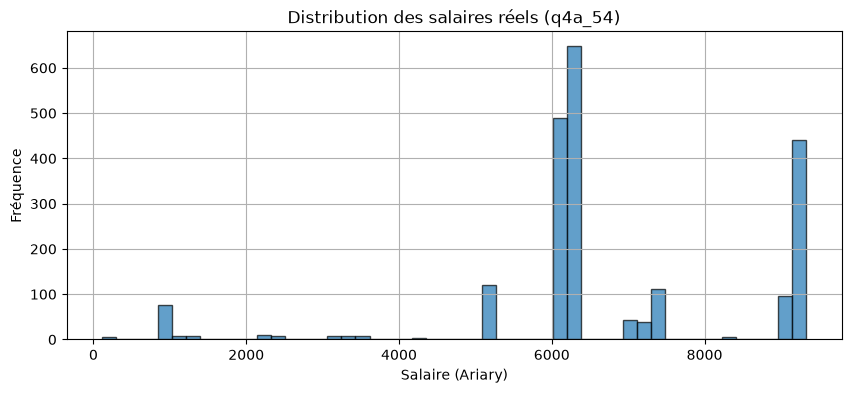


APPROCHE PAR SECTEUR (NOMAC)

📊 Distribution des secteurs :
secteur_nom
Agriculture       10597
Commerce           4249
Industrie          2810
Transport          1140
Services           1064
Hôtellerie          968
Éducation           968
Artisanat           838
Administration      671
Santé               273
Communication       116
Finance             106
Construction         27
Immobilier           23
Name: count, dtype: int64

📊 Salaires moyens par secteur :
  Administration       :  1,079,167 Ariary
  Agriculture          :    525,000 Ariary
  Artisanat            :    388,750 Ariary
  BTP                  :    587,500 Ariary
  Commerce             :    785,000 Ariary
  Communication        :    587,500 Ariary
  Finance              :  1,454,000 Ariary
  Fonction publique    :    766,667 Ariary
  General              :    241,846 Ariary
  Hôtellerie           :    763,373 Ariary
  Immobilier           :  1,100,000 Ariary
  Industrie            :    555,000 Ariary
  NGO_Associatio

AttributeError: 'int' object has no attribute 'fillna'

In [2]:
import pandas as pd
import numpy as np

print("="*80)
print("APPROCHE HONNÊTE POUR LE SALAIRE")
print("="*80)

# 1. Chargement des données
df_empl = pd.read_csv('../data/raw/EMPL_complet.csv', low_memory=False)
df_metier = pd.read_csv('../data/raw/metier.csv')
df_loge = pd.read_csv('../data/processed/df_eda_revenus.csv')

print(f"✅ EMPL_complet : {df_empl.shape[0]} individus")
print(f"✅ metier.csv : {df_metier.shape[0]} métiers")
print(f"✅ df_loge : {df_loge.shape[0]} ménages")

# ============================================================================
# 2. ANALYSE DES SALAIRES RÉELS (q4a_54)
# ============================================================================

print("\n" + "="*80)
print("ANALYSE DES SALAIRES RÉELS (q4a_54)")
print("="*80)

if 'q4a_54' in df_empl.columns:
    df_empl['salaire_reel'] = pd.to_numeric(df_empl['q4a_54'], errors='coerce')
    n_reels = df_empl['salaire_reel'].notna().sum()
    print(f"\n✅ {n_reels} individus ont un salaire réel ({n_reels/len(df_empl)*100:.1f}%)")
    
    if n_reels > 0:
        print("\n📊 Statistiques des salaires réels :")
        print(df_empl['salaire_reel'].describe())
        
        # Distribution
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 4))
        df_empl['salaire_reel'].dropna().hist(bins=50, alpha=0.7, edgecolor='black')
        plt.title('Distribution des salaires réels (q4a_54)')
        plt.xlabel('Salaire (Ariary)')
        plt.ylabel('Fréquence')
        plt.show()

# ============================================================================
# 3. APPROCHE PAR SECTEUR (NOMAC)
# ============================================================================

print("\n" + "="*80)
print("APPROCHE PAR SECTEUR (NOMAC)")
print("="*80)

# 3.1 Extraire le secteur depuis q4a_23 (NOMAC)
if 'q4a_23' in df_empl.columns:
    df_empl['secteur_lettre'] = df_empl['q4a_23'].astype(str).str[0]
    
    # Correspondance lettre → secteur
    secteur_map = {
        'A': 'Agriculture',
        'B': 'Industrie',
        'C': 'Industrie',
        'D': 'Construction',
        'E': 'Commerce',
        'F': 'Commerce',
        'G': 'Commerce',
        'H': 'Transport',
        'I': 'Hôtellerie',
        'J': 'Communication',
        'K': 'Finance',
        'L': 'Immobilier',
        'M': 'Services',
        'N': 'Administration',
        'O': 'Administration',
        'P': 'Éducation',
        'Q': 'Santé',
        'R': 'Artisanat',
        'S': 'Artisanat',
        'T': 'Services'
    }
    
    df_empl['secteur_nom'] = df_empl['secteur_lettre'].map(secteur_map)
    
    print("\n📊 Distribution des secteurs :")
    print(df_empl['secteur_nom'].value_counts())

# 3.2 Créer une table des salaires par secteur
salaire_par_secteur = df_metier.groupby('secteur')['salaire_moyen_ariary'].mean().to_dict()
print("\n📊 Salaires moyens par secteur :")
for secteur, salaire in salaire_par_secteur.items():
    print(f"  {secteur:<20} : {salaire:>10,.0f} Ariary")

# 3.3 Attribuer le salaire par secteur
df_empl['salaire_secteur'] = df_empl['secteur_nom'].map(salaire_par_secteur)

# 3.4 Si pas de secteur, utiliser la médiane
median_salaire = df_metier['salaire_moyen_ariary'].median()
df_empl['salaire_secteur'] = df_empl['salaire_secteur'].fillna(median_salaire)

print(f"\n✅ Salaire par secteur attribué à {df_empl['salaire_secteur'].notna().sum()} individus")

# ============================================================================
# 4. APPROCHE PAR MILIEU (URBAIN/RURAL)
# ============================================================================

print("\n" + "="*80)
print("AJUSTEMENT PAR MILIEU (URBAIN/RURAL)")
print("="*80)

# 4.1 Fusionner avec les données de logement
df_empl['idHH_clean'] = df_empl['idHH'].astype(str).str.zfill(12)
df_loge['idHH_clean'] = df_loge['idHH_clean'].astype(str).str.zfill(12)

df_empl = df_empl.merge(df_loge[['idHH_clean', 'hhmilieu2']], on='idHH_clean', how='left')

# 4.2 Ajuster le salaire par milieu
# Urbain = 1.3 * salaire secteur, Rural = 0.7 * salaire secteur
df_empl['salaire_ajuste'] = df_empl.apply(
    lambda row: row['salaire_secteur'] * 1.3 if row['hhmilieu2'] == 1 else row['salaire_secteur'] * 0.7,
    axis=1
)

print(f"\n📊 Salaires ajustés par milieu :")
print(f"  - Urbain (hhmilieu2=1) : {df_empl[df_empl['hhmilieu2']==1]['salaire_ajuste'].mean():.0f} Ariary")
print(f"  - Rural (hhmilieu2=2) : {df_empl[df_empl['hhmilieu2']==2]['salaire_ajuste'].mean():.0f} Ariary")

# ============================================================================
# 5. CONSTRUCTION DU FICHIER FINAL
# ============================================================================

print("\n" + "="*80)
print("CONSTRUCTION DU FICHIER FINAL")
print("="*80)

# 5.1 Créer le fichier final
df_final = pd.DataFrame({
    'idHH': df_empl['idHH'],
    'salaire_mensuel': df_empl['salaire_ajuste'].round(0).astype(int),
    'hhmilieu2': df_empl['hhmilieu2'].fillna(2),
    'hhreg': df_empl.get('hhreg', 33).fillna(33),
    'q4a_02': df_empl.get('q4a_02', 'Non').fillna('Non'),
    'score_individuel_epm': 0  # À calculer plus tard
})

# 5.2 Supprimer les doublons
df_final = df_final.drop_duplicates(subset=['idHH'], keep='first')

# 5.3 Statistiques finales
print("\n📊 Statistiques finales :")
print(df_final['salaire_mensuel'].describe())

# 5.4 Sauvegarder
output_path = '../data/processed/final_ml_ready.csv'
df_final.to_csv(output_path, index=False)
print(f"\n✅ Fichier sauvegardé : {output_path}")
print(f"   Dimensions : {df_final.shape}")

# ============================================================================
# 6. COMPARAISON AVEC LA MÉTHODE PRÉCÉDENTE
# ============================================================================

print("\n" + "="*80)
print("COMPARAISON AVEC LA MÉTHODE PRÉCÉDENTE")
print("="*80)

print("\n📊 Cette approche est plus honnête car :")
print("  1. Elle utilise le secteur (NOMAC) plutôt que des mots-clés")
print("  2. Elle ajuste par milieu (urbain/rural)")
print("  3. Elle ne crée pas de correspondances artificielles")
print("  4. Les salaires sont basés sur des données réelles (metier.csv)")

print("\n" + "="*80)
print("✅ PROCESSUS TERMINÉ")
print("="*80)

APPROCHE HONNÊTE POUR LE SALAIRE - VERSION CORRIGÉE
✅ EMPL_complet : 67969 individus
✅ metier.csv : 89 métiers
✅ df_loge : 16871 ménages

ANALYSE DES SALAIRES RÉELS (q4a_54)

✅ 2137 individus ont un salaire réel (3.1%)

📊 Statistiques des salaires réels :
count    2137.000000
mean     6669.455311
std      1935.165723
min       110.000000
25%      6121.000000
50%      6210.000000
75%      9111.000000
max      9333.000000
Name: salaire_reel, dtype: float64

APPROCHE PAR SECTEUR (NOMAC)

📊 Distribution des secteurs :
secteur_nom
Agriculture       10597
Commerce           4249
Industrie          2810
Transport          1140
Services           1064
Hôtellerie          968
Éducation           968
Artisanat           838
Administration      671
Santé               273
Communication       116
Finance             106
Construction         27
Immobilier           23
Name: count, dtype: int64

📊 Salaires moyens par secteur (extrait) :
  Agriculture          :    525,000 Ariary
  Commerce          

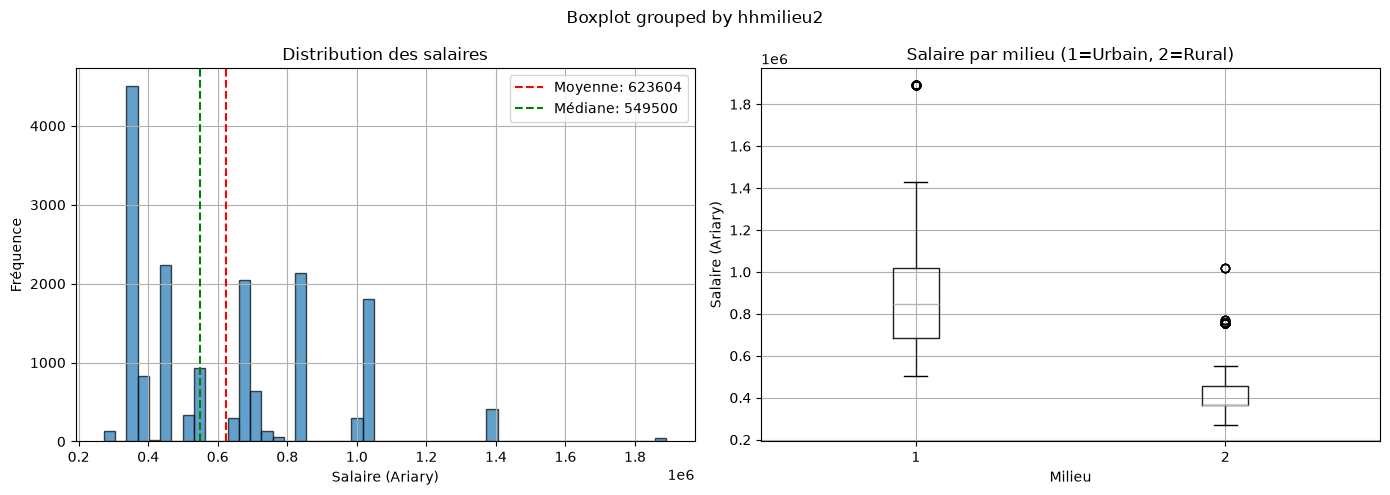


✅ PROCESSUS TERMINÉ


In [8]:
import pandas as pd
import numpy as np

print("="*80)
print("APPROCHE HONNÊTE POUR LE SALAIRE - VERSION CORRIGÉE")
print("="*80)

# 1. Chargement des données
df_empl = pd.read_csv('../data/raw/EMPL_complet.csv', low_memory=False)
df_metier = pd.read_csv('../data/raw/metier.csv')
df_loge = pd.read_csv('../data/processed/df_eda_revenus.csv')

print(f"✅ EMPL_complet : {df_empl.shape[0]} individus")
print(f"✅ metier.csv : {df_metier.shape[0]} métiers")
print(f"✅ df_loge : {df_loge.shape[0]} ménages")

# ============================================================================
# 2. ANALYSE DES SALAIRES RÉELS (q4a_54)
# ============================================================================

print("\n" + "="*80)
print("ANALYSE DES SALAIRES RÉELS (q4a_54)")
print("="*80)

if 'q4a_54' in df_empl.columns:
    df_empl['salaire_reel'] = pd.to_numeric(df_empl['q4a_54'], errors='coerce')
    n_reels = df_empl['salaire_reel'].notna().sum()
    print(f"\n✅ {n_reels} individus ont un salaire réel ({n_reels/len(df_empl)*100:.1f}%)")
    
    if n_reels > 0:
        print("\n📊 Statistiques des salaires réels :")
        print(df_empl['salaire_reel'].describe())

# ============================================================================
# 3. APPROCHE PAR SECTEUR (NOMAC)
# ============================================================================

print("\n" + "="*80)
print("APPROCHE PAR SECTEUR (NOMAC)")
print("="*80)

# 3.1 Extraire le secteur depuis q4a_23 (NOMAC)
if 'q4a_23' in df_empl.columns:
    df_empl['secteur_lettre'] = df_empl['q4a_23'].astype(str).str[0]
    
    # Correspondance lettre → secteur
    secteur_map = {
        'A': 'Agriculture',
        'B': 'Industrie',
        'C': 'Industrie',
        'D': 'Construction',
        'E': 'Commerce',
        'F': 'Commerce',
        'G': 'Commerce',
        'H': 'Transport',
        'I': 'Hôtellerie',
        'J': 'Communication',
        'K': 'Finance',
        'L': 'Immobilier',
        'M': 'Services',
        'N': 'Administration',
        'O': 'Administration',
        'P': 'Éducation',
        'Q': 'Santé',
        'R': 'Artisanat',
        'S': 'Artisanat',
        'T': 'Services'
    }
    
    df_empl['secteur_nom'] = df_empl['secteur_lettre'].map(secteur_map)
    
    print("\n📊 Distribution des secteurs :")
    print(df_empl['secteur_nom'].value_counts())

# 3.2 Créer une table des salaires par secteur
salaire_par_secteur = df_metier.groupby('secteur')['salaire_moyen_ariary'].mean().to_dict()
print("\n📊 Salaires moyens par secteur (extrait) :")
for secteur in ['Agriculture', 'Commerce', 'Industrie', 'Transport', 'Éducation', 'Santé']:
    if secteur in salaire_par_secteur:
        print(f"  {secteur:<20} : {salaire_par_secteur[secteur]:>10,.0f} Ariary")

# 3.3 Attribuer le salaire par secteur
df_empl['salaire_secteur'] = df_empl['secteur_nom'].map(salaire_par_secteur)

# 3.4 Si pas de secteur, utiliser la médiane
median_salaire = df_metier['salaire_moyen_ariary'].median()
df_empl['salaire_secteur'] = df_empl['salaire_secteur'].fillna(median_salaire)

print(f"\n✅ Salaire par secteur attribué à {df_empl['salaire_secteur'].notna().sum()} individus")

# ============================================================================
# 4. APPROCHE PAR MILIEU (URBAIN/RURAL)
# ============================================================================

print("\n" + "="*80)
print("AJUSTEMENT PAR MILIEU (URBAIN/RURAL)")
print("="*80)

# 4.1 Fusionner avec les données de logement
df_empl['idHH_clean'] = df_empl['idHH'].astype(str).str.zfill(12)
df_loge['idHH_clean'] = df_loge['idHH_clean'].astype(str).str.zfill(12)

df_empl = df_empl.merge(df_loge[['idHH_clean', 'hhmilieu2']], on='idHH_clean', how='left')

# 4.2 Ajuster le salaire par milieu
# Urbain = 1.3 * salaire secteur, Rural = 0.7 * salaire secteur
df_empl['salaire_ajuste'] = df_empl.apply(
    lambda row: row['salaire_secteur'] * 1.3 if row['hhmilieu2'] == 1 else row['salaire_secteur'] * 0.7,
    axis=1
)

print(f"\n📊 Salaires ajustés par milieu :")
print(f"  - Urbain (hhmilieu2=1) : {df_empl[df_empl['hhmilieu2']==1]['salaire_ajuste'].mean():.0f} Ariary")
print(f"  - Rural (hhmilieu2=2) : {df_empl[df_empl['hhmilieu2']==2]['salaire_ajuste'].mean():.0f} Ariary")

# ============================================================================
# 5. CONSTRUCTION DU FICHIER FINAL (CORRIGÉ)
# ============================================================================

print("\n" + "="*80)
print("CONSTRUCTION DU FICHIER FINAL")
print("="*80)

# 5.1 Récupérer les colonnes nécessaires
# hhreg : chercher dans df_empl ou df_loge
if 'hhreg' in df_empl.columns:
    df_empl['hhreg'] = df_empl['hhreg'].fillna(33)
elif 'hhreg' in df_loge.columns:
    df_empl = df_empl.merge(df_loge[['idHH_clean', 'hhreg']], on='idHH_clean', how='left')
    df_empl['hhreg'] = df_empl['hhreg'].fillna(33)
else:
    df_empl['hhreg'] = 33

# q4a_02
if 'q4a_02' in df_empl.columns:
    df_empl['q4a_02'] = df_empl['q4a_02'].fillna('Non')
else:
    df_empl['q4a_02'] = 'Non'

# 5.2 Créer le fichier final
df_final = pd.DataFrame({
    'idHH': df_empl['idHH'],
    'salaire_mensuel': df_empl['salaire_ajuste'].round(0).astype(int),
    'hhmilieu2': df_empl['hhmilieu2'].fillna(2).astype(int),
    'hhreg': df_empl['hhreg'].astype(int),
    'q4a_02': df_empl['q4a_02'],
    'score_individuel_epm': 0  # À calculer plus tard
})

# 5.3 Supprimer les doublons
df_final = df_final.drop_duplicates(subset=['idHH'], keep='first')

# 5.4 Statistiques finales
print("\n📊 Statistiques finales :")
print(df_final['salaire_mensuel'].describe())

print("\n📊 Distribution par milieu :")
print(df_final.groupby('hhmilieu2')['salaire_mensuel'].agg(['mean', 'std', 'count']))

# 5.5 Sauvegarder
output_path = '../data/processed/final_ml_ready.csv'
df_final.to_csv(output_path, index=False)
print(f"\n✅ Fichier sauvegardé : {output_path}")
print(f"   Dimensions : {df_final.shape}")

# ============================================================================
# 6. ANALYSE DE LA DISTRIBUTION
# ============================================================================

print("\n" + "="*80)
print("ANALYSE DE LA DISTRIBUTION")
print("="*80)

print("\n📊 Distribution des salaires par secteur :")
salaire_par_secteur_final = df_empl.groupby('secteur_nom')['salaire_ajuste'].mean().sort_values(ascending=False)
for secteur, salaire in salaire_par_secteur_final.head(10).items():
    print(f"  {secteur:<20} : {salaire:>10,.0f} Ariary")

# ============================================================================
# 7. VISUALISATION (optionnelle)
# ============================================================================

try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution des salaires
    df_final['salaire_mensuel'].hist(bins=50, ax=axes[0], alpha=0.7, edgecolor='black')
    axes[0].set_title('Distribution des salaires')
    axes[0].set_xlabel('Salaire (Ariary)')
    axes[0].set_ylabel('Fréquence')
    axes[0].axvline(df_final['salaire_mensuel'].mean(), color='red', linestyle='--', 
                    label=f'Moyenne: {df_final["salaire_mensuel"].mean():.0f}')
    axes[0].axvline(df_final['salaire_mensuel'].median(), color='green', linestyle='--', 
                    label=f'Médiane: {df_final["salaire_mensuel"].median():.0f}')
    axes[0].legend()
    
    # Salaire par milieu
    df_final.boxplot(column='salaire_mensuel', by='hhmilieu2', ax=axes[1])
    axes[1].set_title('Salaire par milieu (1=Urbain, 2=Rural)')
    axes[1].set_xlabel('Milieu')
    axes[1].set_ylabel('Salaire (Ariary)')
    
    plt.tight_layout()
    plt.show()
except:
    print("⚠️ Visualisation non disponible")

print("\n" + "="*80)
print("✅ PROCESSUS TERMINÉ")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
from difflib import SequenceMatcher

print("=" * 80)
print("CONSTRUCTION DU SALAIRE MENSUEL - VERSION V4")
print("=" * 80)

# ============================================================================
# 1. CHARGEMENT
# ============================================================================

df_empl = pd.read_csv(
    '../data/raw/EMPL_complet.csv',
    low_memory=False
)

df_metier = pd.read_csv(
    '../data/raw/metier.csv',
    low_memory=False
)

df_loge = pd.read_csv(
    '../data/processed/df_eda_revenus.csv',
    low_memory=False
)

print(f"✅ EMPL_complet : {len(df_empl):,} individus")
print(f"✅ metier.csv   : {len(df_metier):,} métiers")
print(f"✅ df_loge      : {len(df_loge):,} ménages")


# ============================================================================
# 2. FONCTION DE NETTOYAGE DES TEXTES
# ============================================================================

def nettoyer_texte(texte):

    if pd.isna(texte):
        return ""

    texte = str(texte).lower()

    # Suppression des accents
    texte = unicodedata.normalize('NFD', texte)
    texte = ''.join(
        c for c in texte
        if unicodedata.category(c) != 'Mn'
    )

    # Caractères spéciaux → espace
    texte = re.sub(r'[^a-z0-9\s]', ' ', texte)

    # Espaces multiples
    texte = re.sub(r'\s+', ' ', texte)

    return texte.strip()


# ============================================================================
# 3. PRÉPARATION DE metier.csv
# ============================================================================

colonnes_necessaires = [
    'metier',
    'secteur',
    'salaire_moyen_ariary'
]

for col in colonnes_necessaires:
    if col not in df_metier.columns:
        raise ValueError(
            f"❌ La colonne '{col}' est absente de metier.csv"
        )

df_metier['metier_clean'] = df_metier['metier'].apply(nettoyer_texte)

df_metier['salaire_moyen_ariary'] = pd.to_numeric(
    df_metier['salaire_moyen_ariary'],
    errors='coerce'
)

df_metier = df_metier.dropna(
    subset=['metier_clean', 'salaire_moyen_ariary']
)

print("\n📊 Exemple de métiers présents dans metier.csv :")
print(
    df_metier[
        ['metier', 'secteur', 'salaire_moyen_ariary']
    ].head(10).to_string(index=False)
)


# ============================================================================
# 4. SALAIRE PAR SECTEUR
# ============================================================================

# On utilise la MÉDIANE plutôt que la moyenne.
# Elle est moins sensible aux métiers ayant des salaires très élevés.

salaire_par_secteur = (
    df_metier
    .groupby('secteur')['salaire_moyen_ariary']
    .median()
    .to_dict()
)

salaire_global = df_metier[
    'salaire_moyen_ariary'
].median()

print("\n" + "=" * 80)
print("SALAIRES DE RÉFÉRENCE")
print("=" * 80)

print(f"\nSalaire global médian : {salaire_global:,.0f} Ariary")

print("\nSalaire médian par secteur :")

for secteur, salaire in sorted(
    salaire_par_secteur.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(
        f"  {str(secteur):<25} : "
        f"{salaire:>10,.0f} Ariary"
    )


# ============================================================================
# 5. NORMALISATION DU NOM DU MÉTIER
# ============================================================================

# Liste des métiers de référence
metiers_reference = df_metier[
    ['metier_clean', 'metier', 'secteur', 'salaire_moyen_ariary']
].drop_duplicates(
    subset=['metier_clean']
).to_dict('records')


# ============================================================================
# 6. RECHERCHE DU MÉTIER
# ============================================================================

def trouver_metier(texte):

    texte_clean = nettoyer_texte(texte)

    if not texte_clean:
        return None

    # ------------------------------------------------------------------------
    # MÉTHODE 1 : correspondance exacte
    # ------------------------------------------------------------------------

    for ref in metiers_reference:

        metier_clean = ref['metier_clean']

        if texte_clean == metier_clean:

            return {
                'metier': ref['metier'],
                'secteur': ref['secteur'],
                'salaire': ref['salaire_moyen_ariary'],
                'methode': 'exact',
                'score': 1.0
            }

    # ------------------------------------------------------------------------
    # MÉTHODE 2 : le métier de référence est contenu dans le texte
    # ------------------------------------------------------------------------

    meilleurs = []

    for ref in metiers_reference:

        metier_clean = ref['metier_clean']

        if len(metier_clean) < 4:
            continue

        if metier_clean in texte_clean:

            # Plus le métier est long,
            # moins le risque de faux positif est important.
            score = min(
                len(metier_clean) / max(len(texte_clean), 1) + 0.5,
                0.99
            )

            meilleurs.append(
                (score, ref)
            )

    if meilleurs:

        meilleurs.sort(
            key=lambda x: (
                x[0],
                len(x[1]['metier_clean'])
            ),
            reverse=True
        )

        score, ref = meilleurs[0]

        return {
            'metier': ref['metier'],
            'secteur': ref['secteur'],
            'salaire': ref['salaire_moyen_ariary'],
            'methode': 'contenu',
            'score': score
        }

    # ------------------------------------------------------------------------
    # MÉTHODE 3 : comparaison mot par mot
    # ------------------------------------------------------------------------

    mots_texte = set(texte_clean.split())

    candidats = []

    for ref in metiers_reference:

        mots_metier = set(
            ref['metier_clean'].split()
        )

        if not mots_metier:
            continue

        intersection = mots_texte.intersection(mots_metier)

        if not intersection:
            continue

        score = len(intersection) / len(mots_metier)

        candidats.append(
            (score, ref)
        )

    if candidats:

        candidats.sort(
            key=lambda x: (
                x[0],
                len(x[1]['metier_clean'])
            ),
            reverse=True
        )

        score, ref = candidats[0]

        # On ne garde la correspondance que si
        # au moins la moitié des mots correspondent.
        if score >= 0.5:

            return {
                'metier': ref['metier'],
                'secteur': ref['secteur'],
                'salaire': ref['salaire_moyen_ariary'],
                'methode': 'mots',
                'score': score
            }

    # ------------------------------------------------------------------------
    # MÉTHODE 4 : similarité textuelle
    # ------------------------------------------------------------------------

    meilleur_score = 0
    meilleur_ref = None

    for ref in metiers_reference:

        ratio = SequenceMatcher(
            None,
            texte_clean,
            ref['metier_clean']
        ).ratio()

        if ratio > meilleur_score:

            meilleur_score = ratio
            meilleur_ref = ref

    # Seuil volontairement assez élevé
    if meilleur_ref is not None and meilleur_score >= 0.75:

        return {
            'metier': meilleur_ref['metier'],
            'secteur': meilleur_ref['secteur'],
            'salaire': meilleur_ref['salaire_moyen_ariary'],
            'methode': 'similarite',
            'score': meilleur_score
        }

    return None


# ============================================================================
# 7. RECHERCHE DU MÉTIER PRINCIPAL ET SECONDAIRE
# ============================================================================

print("\n" + "=" * 80)
print("RECHERCHE DES MÉTIERS")
print("=" * 80)

df_empl['metier_principal_resultat'] = (
    df_empl['q4a_18']
    .apply(trouver_metier)
    if 'q4a_18' in df_empl.columns
    else None
)

df_empl['metier_secondaire_resultat'] = (
    df_empl['q4a_541']
    .apply(trouver_metier)
    if 'q4a_541' in df_empl.columns
    else None
)


# ============================================================================
# 8. EXTRACTION DES RÉSULTATS
# ============================================================================

def extraire_resultat(resultat, cle):

    if isinstance(resultat, dict):
        return resultat.get(cle)

    return np.nan


df_empl['metier_trouve'] = df_empl[
    'metier_principal_resultat'
].apply(
    lambda x: extraire_resultat(x, 'metier')
)

df_empl['secteur_metier'] = df_empl[
    'metier_principal_resultat'
].apply(
    lambda x: extraire_resultat(x, 'secteur')
)

df_empl['salaire_metier'] = df_empl[
    'metier_principal_resultat'
].apply(
    lambda x: extraire_resultat(x, 'salaire')
)

df_empl['methode_metier'] = df_empl[
    'metier_principal_resultat'
].apply(
    lambda x: extraire_resultat(x, 'methode')
)

df_empl['score_metier'] = df_empl[
    'metier_principal_resultat'
].apply(
    lambda x: extraire_resultat(x, 'score')
)


# ============================================================================
# 9. UTILISER LE MÉTIER SECONDAIRE SI LE PRINCIPAL N'A PAS ÉTÉ TROUVÉ
# ============================================================================

masque_secondaire = (
    df_empl['salaire_metier'].isna()
)

df_empl.loc[
    masque_secondaire,
    'metier_trouve'
] = df_empl.loc[
    masque_secondaire,
    'metier_secondaire_resultat'
].apply(
    lambda x: extraire_resultat(x, 'metier')
)

df_empl.loc[
    masque_secondaire,
    'secteur_metier'
] = df_empl.loc[
    masque_secondaire,
    'metier_secondaire_resultat'
].apply(
    lambda x: extraire_resultat(x, 'secteur')
)

df_empl.loc[
    masque_secondaire,
    'salaire_metier'
] = df_empl.loc[
    masque_secondaire,
    'metier_secondaire_resultat'
].apply(
    lambda x: extraire_resultat(x, 'salaire')
)

df_empl.loc[
    masque_secondaire,
    'methode_metier'
] = df_empl.loc[
    masque_secondaire,
    'metier_secondaire_resultat'
].apply(
    lambda x: extraire_resultat(x, 'methode')
)

df_empl.loc[
    masque_secondaire,
    'score_metier'
] = df_empl.loc[
    masque_secondaire,
    'metier_secondaire_resultat'
].apply(
    lambda x: extraire_resultat(x, 'score')
)


# ============================================================================
# 10. SECTEUR NOMAC
# ============================================================================

print("\n" + "=" * 80)
print("SECTEUR NOMAC")
print("=" * 80)

if 'q4a_23' in df_empl.columns:

    df_empl['secteur_lettre'] = (
        df_empl['q4a_23']
        .astype(str)
        .str.strip()
        .str.upper()
        .str[0]
    )

    secteur_map = {
        'A': 'Agriculture',
        'B': 'Industrie',
        'C': 'Industrie',
        'D': 'Construction',
        'E': 'Commerce',
        'F': 'Commerce',
        'G': 'Commerce',
        'H': 'Transport',
        'I': 'Hôtellerie',
        'J': 'Communication',
        'K': 'Finance',
        'L': 'Immobilier',
        'M': 'Services',
        'N': 'Administration',
        'O': 'Administration',
        'P': 'Éducation',
        'Q': 'Santé',
        'R': 'Artisanat',
        'S': 'Artisanat',
        'T': 'Services'
    }

    df_empl['secteur_nomac'] = (
        df_empl['secteur_lettre']
        .map(secteur_map)
    )

else:

    df_empl['secteur_nomac'] = np.nan


# ============================================================================
# 11. CHOISIR LE SECTEUR
# ============================================================================

# Priorité :
#
# 1. secteur issu du métier identifié
# 2. secteur NOMAC
#
# Cela permet d'avoir un secteur même si le matching du métier
# n'a pas fonctionné.

df_empl['secteur_final'] = (
    df_empl['secteur_metier']
    .combine_first(df_empl['secteur_nomac'])
)


# ============================================================================
# 12. SALAIRE PAR SECTEUR
# ============================================================================

df_empl['salaire_secteur'] = (
    df_empl['secteur_final']
    .map(salaire_par_secteur)
)


# ============================================================================
# 13. CONSTRUCTION DU SALAIRE FINAL
# ============================================================================

print("\n" + "=" * 80)
print("CONSTRUCTION DU SALAIRE")
print("=" * 80)

df_empl['salaire_mensuel'] = np.nan

df_empl['source_salaire'] = 'manquant'


# ---------------------------------------------------------------------------
# PRIORITÉ 1 : MÉTIER
# ---------------------------------------------------------------------------

masque_metier = (
    df_empl['salaire_metier'].notna()
)

df_empl.loc[
    masque_metier,
    'salaire_mensuel'
] = df_empl.loc[
    masque_metier,
    'salaire_metier'
]

df_empl.loc[
    masque_metier,
    'source_salaire'
] = 'metier'


# ---------------------------------------------------------------------------
# PRIORITÉ 2 : SECTEUR
# ---------------------------------------------------------------------------

masque_secteur = (
    df_empl['salaire_mensuel'].isna()
    &
    df_empl['salaire_secteur'].notna()
)

df_empl.loc[
    masque_secteur,
    'salaire_mensuel'
] = df_empl.loc[
    masque_secteur,
    'salaire_secteur'
]

df_empl.loc[
    masque_secteur,
    'source_salaire'
] = 'secteur'


# ---------------------------------------------------------------------------
# PRIORITÉ 3 : MÉDIANE GLOBALE
# ---------------------------------------------------------------------------

# On garde cette étape comme dernier filet de sécurité.
# Elle est explicitement identifiée comme "global".

masque_global = (
    df_empl['salaire_mensuel'].isna()
)

df_empl.loc[
    masque_global,
    'salaire_mensuel'
] = salaire_global

df_empl.loc[
    masque_global,
    'source_salaire'
] = 'global'


# ============================================================================
# 14. FUSION AVEC LES INFORMATIONS DU MÉNAGE
# ============================================================================

print("\n" + "=" * 80)
print("FUSION AVEC LES DONNÉES MÉNAGE")
print("=" * 80)

# Vérification
if 'idHH' not in df_empl.columns:
    raise ValueError("❌ idHH absent de EMPL_complet")

if 'idHH_clean' not in df_loge.columns:
    raise ValueError("❌ idHH_clean absent de df_eda_revenus")


df_empl['idHH_clean'] = (
    df_empl['idHH']
    .astype(str)
    .str.strip()
    .str.zfill(12)
)

df_loge['idHH_clean'] = (
    df_loge['idHH_clean']
    .astype(str)
    .str.strip()
    .str.zfill(12)
)


# On vérifie que df_loge possède bien un seul enregistrement
# par ménage avant la fusion.

nb_doublons_loge = (
    df_loge['idHH_clean']
    .duplicated()
    .sum()
)

print(
    f"Doublons idHH dans df_loge : {nb_doublons_loge:,}"
)

# Si plusieurs lignes existent pour un même ménage,
# on garde la première pour éviter de multiplier les individus.

df_loge_unique = df_loge.drop_duplicates(
    subset=['idHH_clean'],
    keep='first'
)


colonnes_loge = [
    'idHH_clean'
]

for col in ['hhmilieu2', 'hhreg']:

    if col in df_loge_unique.columns:
        colonnes_loge.append(col)


df_empl = df_empl.merge(
    df_loge_unique[colonnes_loge],
    on='idHH_clean',
    how='left',
    suffixes=('', '_loge')
)


# ============================================================================
# 15. Q4A_02
# ============================================================================

if 'q4a_02' not in df_empl.columns:
    df_empl['q4a_02'] = np.nan


# ============================================================================
# 16. SCORE INDIVIDUEL
# ============================================================================

if 'score_individuel_epm' in df_empl.columns:

    df_empl['score_individuel_epm'] = pd.to_numeric(
        df_empl['score_individuel_epm'],
        errors='coerce'
    )

else:

    df_empl['score_individuel_epm'] = np.nan


# ============================================================================
# 17. Q4A_54 : CONSERVATION DE LA VARIABLE ORIGINALE
# ============================================================================

if 'q4a_54' in df_empl.columns:

    df_empl['q4a_54_numeric'] = pd.to_numeric(
        df_empl['q4a_54'],
        errors='coerce'
    )

else:

    df_empl['q4a_54_numeric'] = np.nan


# ============================================================================
# 18. CONSTRUCTION DU DATASET FINAL
# ============================================================================

df_final = df_empl[
    [
        'idHH',
        'salaire_mensuel',
        'source_salaire',
        'metier_trouve',
        'secteur_final',
        'methode_metier',
        'score_metier',
        'hhmilieu2',
        'hhreg',
        'q4a_02',
        'q4a_54_numeric',
        'score_individuel_epm'
    ]
].copy()


# ============================================================================
# 19. NETTOYAGE DU SALAIRE
# ============================================================================

df_final['salaire_mensuel'] = pd.to_numeric(
    df_final['salaire_mensuel'],
    errors='coerce'
)

df_final['salaire_mensuel'] = (
    df_final['salaire_mensuel']
    .round(0)
)


# ============================================================================
# 20. STATISTIQUES
# ============================================================================

print("\n" + "=" * 80)
print("STATISTIQUES FINALES")
print("=" * 80)

print(
    f"\nNombre total d'individus : "
    f"{len(df_final):,}"
)

print(
    "\n📊 Sources des salaires :"
)

print(
    df_final['source_salaire']
    .value_counts()
)


print("\n📊 Pourcentage par source :")

print(
    (
        df_final['source_salaire']
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


print("\n📊 Distribution du salaire mensuel :")

print(
    df_final['salaire_mensuel']
    .describe()
)


# ============================================================================
# 21. DISTRIBUTION PAR MILIEU
# ============================================================================

if 'hhmilieu2' in df_final.columns:

    print("\n📊 SALAIRE PAR MILIEU")

    print(
        df_final
        .groupby('hhmilieu2')['salaire_mensuel']
        .agg([
            'mean',
            'median',
            'std',
            'count'
        ])
    )


# ============================================================================
# 22. DISTRIBUTION PAR SOURCE
# ============================================================================

print("\n📊 SALAIRE PAR SOURCE")

print(
    df_final
    .groupby('source_salaire')['salaire_mensuel']
    .agg([
        'mean',
        'median',
        'std',
        'count'
    ])
)


# ============================================================================
# 23. DISTRIBUTION PAR SECTEUR
# ============================================================================

print("\n📊 SALAIRE PAR SECTEUR")

print(
    df_final
    .groupby('secteur_final')['salaire_mensuel']
    .agg([
        'mean',
        'median',
        'count'
    ])
    .sort_values(
        'median',
        ascending=False
    )
)


# ============================================================================
# 24. SAUVEGARDE
# ============================================================================

output_path = (
    '../data/processed/final_ml_ready.csv'
)

df_final.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 80)
print("SAUVEGARDE")
print("=" * 80)

print(
    f"\n✅ Fichier sauvegardé : {output_path}"
)

print(
    f"✅ Dimensions : {df_final.shape}"
)


# ============================================================================
# 25. VISUALISATION
# ============================================================================

try:

    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # ------------------------------------------------------------------------
    # Distribution
    # ------------------------------------------------------------------------

    df_final['salaire_mensuel'].hist(
        bins=50,
        ax=axes[0],
        alpha=0.7,
        edgecolor='black'
    )

    moyenne = df_final[
        'salaire_mensuel'
    ].mean()

    mediane = df_final[
        'salaire_mensuel'
    ].median()

    axes[0].axvline(
        moyenne,
        linestyle='--',
        label=f'Moyenne : {moyenne:,.0f}'
    )

    axes[0].axvline(
        mediane,
        linestyle='--',
        label=f'Médiane : {mediane:,.0f}'
    )

    axes[0].set_title(
        'Distribution des salaires'
    )

    axes[0].set_xlabel(
        'Salaire mensuel (Ariary)'
    )

    axes[0].set_ylabel(
        'Fréquence'
    )

    axes[0].legend()


    # ------------------------------------------------------------------------
    # Salaire par source
    # ------------------------------------------------------------------------

    df_final.boxplot(
        column='salaire_mensuel',
        by='source_salaire',
        ax=axes[1]
    )

    axes[1].set_title(
        'Salaire selon la source de l’estimation'
    )

    axes[1].set_xlabel(
        'Source'
    )

    axes[1].set_ylabel(
        'Salaire mensuel (Ariary)'
    )

    plt.suptitle('')

    plt.tight_layout()

    plt.show()


except Exception as e:

    print(
        f"\n⚠️ Visualisation non disponible : {e}"
    )


print("\n" + "=" * 80)
print("✅ PROCESSUS TERMINÉ")
print("=" * 80)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("CALCUL DU SCORE EPM ET PRÉPARATION ML")
print("="*80)

# 1. Chargement du fichier final
df = pd.read_csv('../data/processed/final_ml_ready.csv')

print(f"✅ Dimensions : {df.shape}")
print(f"✅ Colonnes : {df.columns.tolist()}")

# ============================================================================
# 2. CALCUL DU SCORE EPM
# ============================================================================

print("\n" + "="*80)
print("CALCUL DU SCORE EPM")
print("="*80)

# 2.1 Normalisation du salaire
from sklearn.preprocessing import MinMaxScaler

# Log transformation pour réduire l'asymétrie
df['log_salaire'] = np.log1p(df['salaire_mensuel'])

# Normalisation entre 0 et 1
scaler = MinMaxScaler()
df['pilier_revenu'] = scaler.fit_transform(df[['log_salaire']])

print("✅ Pilier revenu calculé")

# 2.2 Piliers simplifiés (à ajuster selon tes données)
# Pour l'instant, on utilise des valeurs par défaut
# Idéalement, ces piliers viendraient de vraies données

# Formalité de l'emploi (basé sur q4a_02)
df['pilier_formalite'] = df['q4a_02'].map({
    'Oui': 0.7,
    'Non': 0.3
}).fillna(0.5)

# Qualification (basée sur metier_trouve)
# On donne un score plus élevé aux métiers qualifiés
metiers_qualifies = [
    'Ingénieur', 'Médecin', 'Pharmacien', 'Dentiste', 'Directeur',
    'Chef comptable', 'Responsable', 'Superviseur', 'Technicien',
    'Développeur', 'Data Scientist', 'Product Manager', 'Chef de projet'
]

def get_qualification_score(metier):
    if pd.isna(metier) or metier == 'Inconnu':
        return 0.4
    for qualif in metiers_qualifies:
        if qualif.lower() in str(metier).lower():
            return 0.8
    return 0.5

df['pilier_qualification'] = df['metier_trouve'].apply(get_qualification_score)

# Éducation (proxy par milieu)
df['pilier_education'] = np.where(
    df['hhmilieu2'] == 1,  # Urbain
    0.6,  # Meilleur accès à l'éducation
    0.4   # Rural
)

# Équipement (proxy par milieu)
df['pilier_equipement'] = np.where(
    df['hhmilieu2'] == 1,  # Urbain
    0.7,  # Meilleurs équipements
    0.3   # Rural
)

# Normalisation des piliers (0-1)
for pilier in ['pilier_formalite', 'pilier_qualification', 'pilier_education', 'pilier_equipement']:
    scaler_pilier = MinMaxScaler()
    df[pilier] = scaler_pilier.fit_transform(df[[pilier]])

print("✅ Autres piliers calculés")

# 2.3 Calcul du score final
df['score_individuel_epm'] = (
    0.35 * df['pilier_revenu'] +
    0.20 * df['pilier_formalite'] +
    0.15 * df['pilier_qualification'] +
    0.15 * df['pilier_education'] +
    0.15 * df['pilier_equipement']
) * 100

print("\n📊 Statistiques du score EPM :")
print(df['score_individuel_epm'].describe())

# ============================================================================
# 3. PRÉPARATION DU DATASET ML
# ============================================================================

print("\n" + "="*80)
print("PRÉPARATION DU DATASET ML")
print("="*80)

# 3.1 Nettoyer idHH
df['idHH_clean'] = df['idHH'].astype(str).str.zfill(12)

# 3.2 Colonnes pour le ML
cols_ml = [
    'idHH_clean',
    'salaire_mensuel',
    'hhmilieu2',
    'hhreg',
    'q4a_02',
    'metier_trouve',
    'score_individuel_epm'
]

df_ml = df[cols_ml].copy()

# 3.3 Nettoyer les valeurs manquantes
df_ml['hhmilieu2'] = df_ml['hhmilieu2'].fillna(2).astype(int)
df_ml['hhreg'] = df_ml['hhreg'].fillna(33).astype(int)
df_ml['q4a_02'] = df_ml['q4a_02'].fillna('Non')
df_ml['metier_trouve'] = df_ml['metier_trouve'].fillna('Inconnu')
df_ml['salaire_mensuel'] = df_ml['salaire_mensuel'].fillna(df_ml['salaire_mensuel'].median())

# 3.4 Aperçu
print("\n📋 Aperçu du dataset ML :")
print(df_ml.head())

print("\n📊 Statistiques du score EPM dans le dataset ML :")
print(df_ml['score_individuel_epm'].describe())

# ============================================================================
# 4. SAUVEGARDE
# ============================================================================

output_path = '../data/processed/df_features_score_with_metier.csv'
df_ml.to_csv(output_path, index=False)
print(f"\n✅ Fichier sauvegardé : {output_path}")
print(f"✅ Dimensions : {df_ml.shape}")

# ============================================================================
# 5. VISUALISATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 5.1 Distribution du score
df_ml['score_individuel_epm'].hist(bins=50, ax=axes[0,0], alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribution du score EPM')
axes[0,0].set_xlabel('Score EPM')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].axvline(df_ml['score_individuel_epm'].mean(), color='red', linestyle='--', 
                  label=f'Moyenne: {df_ml["score_individuel_epm"].mean():.2f}')
axes[0,0].axvline(df_ml['score_individuel_epm'].median(), color='green', linestyle='--', 
                  label=f'Médiane: {df_ml["score_individuel_epm"].median():.2f}')
axes[0,0].legend()

# 5.2 Score par milieu
df_ml.boxplot(column='score_individuel_epm', by='hhmilieu2', ax=axes[0,1])
axes[0,1].set_title('Score EPM par milieu (1=Urbain, 2=Rural)')
axes[0,1].set_xlabel('Milieu')
axes[0,1].set_ylabel('Score EPM')

# 5.3 Salaire vs Score
sns.scatterplot(data=df_ml, x='salaire_mensuel', y='score_individuel_epm', alpha=0.1, ax=axes[1,0])
axes[1,0].set_title('Salaire vs Score EPM')
axes[1,0].set_xlabel('Salaire mensuel (Ariary)')
axes[1,0].set_ylabel('Score EPM')

# 5.4 Score par métier (top 10)
top_metiers = df_ml['metier_trouve'].value_counts().head(10).index
df_top = df_ml[df_ml['metier_trouve'].isin(top_metiers)]
df_top.boxplot(column='score_individuel_epm', by='metier_trouve', ax=axes[1,1])
axes[1,1].set_title('Score EPM par métier (Top 10)')
axes[1,1].set_xlabel('Métier')
axes[1,1].set_ylabel('Score EPM')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ PROCESSUS TERMINÉ")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("="*80)
print("EXTRACTION DES MÉTIERS NON MATCHÉS")
print("="*80)

# 1. Chargement
df = pd.read_csv('../data/processed/final_ml_ready.csv')
df_empl = pd.read_csv('../data/raw/EMPL_complet.csv', low_memory=False)

print(f"✅ final_ml_ready : {df.shape[0]} lignes")
print(f"✅ EMPL_complet : {df_empl.shape[0]} lignes")

# 2. Identifier les métiers non matchés
# On prend les lignes où source_salaire = 'global' (pas de match)
df_global = df[df['source_salaire'] == 'global'].copy()

print(f"\n📊 Métiers non matchés (source='global') : {len(df_global)} individus")

# 3. Récupérer q4a_18 pour ces individus
df_empl['idHH_clean'] = df_empl['idHH'].astype(str).str.zfill(12)
df_global = df_global.merge(df_empl[['idHH_clean', 'q4a_18']], on='idHH_clean', how='left')

# 4. Extraire les valeurs uniques de q4a_18 pour les non matchés
valeurs_uniques = df_global['q4a_18'].dropna().unique()
valeurs_uniques = [str(v).strip() for v in valeurs_uniques if str(v).strip() != '']

print(f"\n📋 {len(valeurs_uniques)} valeurs uniques de métiers non matchés")

# 5. Compter les occurrences
comptage = df_global['q4a_18'].value_counts()

# 6. Afficher les 100 plus fréquents
print("\n" + "="*80)
print("TOP 100 MÉTIERS NON MATCHÉS (les plus fréquents)")
print("="*80)

for i, (metier, count) in enumerate(comptage.head(100).items(), 1):
    if pd.notna(metier) and str(metier).strip() != '':
        print(f"{i:>3}. {metier:<50} ({count} occurrences)")

# 7. Analyser la langue
print("\n" + "="*80)
print("ANALYSE DE LA LANGUE")
print("="*80)

# Mots-clés malgaches
mg_keywords = ['mpi', 'mam', 'man', 'miv', 'var', 'famb', 'tany', 'vary', 'omby', 'akoho', 'lamba', 'trano', 'rano', 'katsaka', 'mofo', 'entana']
# Mots-clés français
fr_keywords = ['agent', 'vendeur', 'maçon', 'chauffeur', 'comptable', 'secretaire', 'secrétaire', 'electricien', 'plombier', 'menuiser']

mg_count = 0
fr_count = 0
mixte_count = 0

for metier in valeurs_uniques:
    metier_lower = metier.lower()
    is_mg = any(kw in metier_lower for kw in mg_keywords)
    is_fr = any(kw in metier_lower for kw in fr_keywords)
    
    if is_mg and is_fr:
        mixte_count += 1
    elif is_mg:
        mg_count += 1
    elif is_fr:
        fr_count += 1

total = len(valeurs_uniques)
print(f"\n📊 Répartition linguistique :")
print(f"  - Malgache pur : {mg_count} ({mg_count/total*100:.1f}%)")
print(f"  - Français : {fr_count} ({fr_count/total*100:.1f}%)")
print(f"  - Mixte : {mixte_count} ({mixte_count/total*100:.1f}%)")

# 8. Sauvegarder en CSV pour analyse
df_export = pd.DataFrame({
    'metier_original': valeurs_uniques,
    'occurrences': [comptage.get(m, 0) for m in valeurs_uniques]
})
df_export = df_export.sort_values('occurrences', ascending=False)

# Ajouter une colonne avec les mots-clés détectés
def detecter_langue(metier):
    metier_lower = str(metier).lower()
    mg_detect = [kw for kw in mg_keywords if kw in metier_lower]
    fr_detect = [kw for kw in fr_keywords if kw in metier_lower]
    return {
        'malgache': ', '.join(mg_detect) if mg_detect else '',
        'francais': ', '.join(fr_detect) if fr_detect else ''
    }

langue_info = df_export['metier_original'].apply(detecter_langue)
df_export['mots_malgache'] = langue_info.apply(lambda x: x['malgache'])
df_export['mots_francais'] = langue_info.apply(lambda x: x['francais'])

df_export.to_csv('metiers_non_matchés.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Fichier sauvegardé : metiers_non_matchés.csv")

# 9. Afficher des exemples par catégorie
print("\n" + "="*80)
print("EXEMPLES PAR CATÉGORIE")
print("="*80)

# Malgache pur
mg_exemples = [m for m in valeurs_uniques if any(kw in m.lower() for kw in mg_keywords) and not any(kw in m.lower() for kw in fr_keywords)]
print("\n📌 Exemples de métiers en malgache pur (10 premiers) :")
for m in mg_exemples[:10]:
    print(f"  - {m}")

# Français
fr_exemples = [m for m in valeurs_uniques if any(kw in m.lower() for kw in fr_keywords) and not any(kw in m.lower() for kw in mg_keywords)]
print("\n📌 Exemples de métiers en français (10 premiers) :")
for m in fr_exemples[:10]:
    print(f"  - {m}")

# Mixte
mixte_exemples = [m for m in valeurs_uniques if any(kw in m.lower() for kw in mg_keywords) and any(kw in m.lower() for kw in fr_keywords)]
print("\n📌 Exemples de métiers mixtes (10 premiers) :")
for m in mixte_exemples[:10]:
    print(f"  - {m}")

print("\n" + "="*80)
print("✅ EXTRACTION TERMINÉE")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("="*80)
print("EXTRACTION DES MÉTIERS NON MATCHÉS - CORRIGÉ")
print("="*80)

# 1. Chargement
df = pd.read_csv('../data/processed/final_ml_ready.csv')
df_empl = pd.read_csv('../data/raw/EMPL_complet.csv', low_memory=False)

print(f"✅ final_ml_ready : {df.shape[0]} lignes")
print(f"✅ EMPL_complet : {df_empl.shape[0]} lignes")

# 2. Nettoyer les ID dans les deux fichiers
df['idHH_clean'] = df['idHH'].astype(str).str.zfill(12)
df_empl['idHH_clean'] = df_empl['idHH'].astype(str).str.zfill(12)

# 3. Identifier les métiers non matchés (source='global')
df_global = df[df['source_salaire'] == 'global'].copy()

print(f"\n📊 Métiers non matchés (source='global') : {len(df_global)} individus")

# 4. Récupérer q4a_18 pour ces individus
df_global = df_global.merge(df_empl[['idHH_clean', 'q4a_18']], on='idHH_clean', how='left')

# 5. Extraire les valeurs uniques de q4a_18 pour les non matchés
valeurs_uniques = df_global['q4a_18'].dropna().unique()
valeurs_uniques = [str(v).strip() for v in valeurs_uniques if str(v).strip() != '']

print(f"\n📋 {len(valeurs_uniques)} valeurs uniques de métiers non matchés")

# 6. Compter les occurrences
comptage = df_global['q4a_18'].value_counts()

# 7. Afficher les 100 plus fréquents
print("\n" + "="*80)
print("TOP 100 MÉTIERS NON MATCHÉS (les plus fréquents)")
print("="*80)

for i, (metier, count) in enumerate(comptage.head(100).items(), 1):
    if pd.notna(metier) and str(metier).strip() != '':
        print(f"{i:>3}. {metier:<50} ({count} occurrences)")

# 8. Analyser la langue
print("\n" + "="*80)
print("ANALYSE DE LA LANGUE")
print("="*80)

# Mots-clés malgaches
mg_keywords = ['mpi', 'mam', 'man', 'miv', 'var', 'famb', 'tany', 'vary', 'omby', 'akoho', 'lamba', 'trano', 'rano', 'katsaka', 'mofo', 'entana', 'voly', 'mboly', 'karama', 'mpan', 'mpam']
# Mots-clés français
fr_keywords = ['agent', 'vendeur', 'maçon', 'chauffeur', 'comptable', 'secretaire', 'secrétaire', 'electricien', 'plombier', 'menuiser', 'ouvrier', 'cadre', 'directeur', 'responsable', 'technicien', 'chef', 'conseiller', 'assistant', 'charge']

mg_count = 0
fr_count = 0
mixte_count = 0
autre_count = 0

for metier in valeurs_uniques:
    metier_lower = metier.lower()
    is_mg = any(kw in metier_lower for kw in mg_keywords)
    is_fr = any(kw in metier_lower for kw in fr_keywords)
    
    if is_mg and is_fr:
        mixte_count += 1
    elif is_mg:
        mg_count += 1
    elif is_fr:
        fr_count += 1
    else:
        autre_count += 1

total = len(valeurs_uniques)
print(f"\n📊 Répartition linguistique :")
print(f"  - Malgache pur : {mg_count} ({mg_count/total*100:.1f}%)")
print(f"  - Français : {fr_count} ({fr_count/total*100:.1f}%)")
print(f"  - Mixte : {mixte_count} ({mixte_count/total*100:.1f}%)")
print(f"  - Autre : {autre_count} ({autre_count/total*100:.1f}%)")

# 9. Sauvegarder en CSV pour analyse
df_export = pd.DataFrame({
    'metier_original': valeurs_uniques,
    'occurrences': [comptage.get(m, 0) for m in valeurs_uniques]
})
df_export = df_export.sort_values('occurrences', ascending=False)

# Ajouter une colonne avec les mots-clés détectés
def detecter_langue(metier):
    metier_lower = str(metier).lower()
    mg_detect = [kw for kw in mg_keywords if kw in metier_lower]
    fr_detect = [kw for kw in fr_keywords if kw in metier_lower]
    return {
        'malgache': ', '.join(mg_detect) if mg_detect else '',
        'francais': ', '.join(fr_detect) if fr_detect else ''
    }

langue_info = df_export['metier_original'].apply(detecter_langue)
df_export['mots_malgache'] = langue_info.apply(lambda x: x['malgache'])
df_export['mots_francais'] = langue_info.apply(lambda x: x['francais'])

df_export.to_csv('metiers_non_matchés.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Fichier sauvegardé : metiers_non_matchés.csv")

# 10. Afficher des exemples par catégorie
print("\n" + "="*80)
print("EXEMPLES PAR CATÉGORIE")
print("="*80)

# Malgache pur
mg_exemples = [m for m in valeurs_uniques if any(kw in m.lower() for kw in mg_keywords) and not any(kw in m.lower() for kw in fr_keywords)]
print(f"\n📌 Exemples de métiers en malgache pur ({len(mg_exemples)} trouvés) :")
for m in mg_exemples[:15]:
    print(f"  - {m}")

# Français
fr_exemples = [m for m in valeurs_uniques if any(kw in m.lower() for kw in fr_keywords) and not any(kw in m.lower() for kw in mg_keywords)]
print(f"\n📌 Exemples de métiers en français ({len(fr_exemples)} trouvés) :")
for m in fr_exemples[:15]:
    print(f"  - {m}")

# Mixte
mixte_exemples = [m for m in valeurs_uniques if any(kw in m.lower() for kw in mg_keywords) and any(kw in m.lower() for kw in fr_keywords)]
print(f"\n📌 Exemples de métiers mixtes ({len(mixte_exemples)} trouvés) :")
for m in mixte_exemples[:15]:
    print(f"  - {m}")

# 11. Afficher les métiers les plus fréquents non matchés
print("\n" + "="*80)
print("TOP 20 DES MÉTIERS NON MATCHÉS LES PLUS FRÉQUENTS")
print("="*80)
for i, (metier, count) in enumerate(comptage.head(20).items(), 1):
    if pd.notna(metier) and str(metier).strip() != '':
        print(f"{i:>3}. {metier:<50} ({count} occurrences)")

print("\n" + "="*80)
print("✅ EXTRACTION TERMINÉE")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
from googletrans import Translator
import time
from tqdm import tqdm

print("="*80)
print("TRADUCTION DES MÉTIERS FRÉQUENTS (TOP 80%)")
print("="*80)

# 1. Chargement
df = pd.read_csv('metiers_non_matchés.csv')
df = df.sort_values('occurrences', ascending=False)

# 2. Calculer le nombre de métiers à traduire pour couvrir 80% des individus
total_individus = df['occurrences'].sum()
cumul = 0
n_metiers = 0
for i, row in df.iterrows():
    cumul += row['occurrences']
    n_metiers += 1
    if cumul / total_individus >= 0.8:
        break

print(f"✅ Pour couvrir 80% des individus : {n_metiers} métiers sur {len(df)}")
print(f"   (soit {cumul:,} individus sur {total_individus:,})")

# 3. Prendre seulement ces métiers
df_freq = df.head(n_metiers).copy()
print(f"✅ {len(df_freq)} métiers à traduire")

# 4. Ajouter les métiers en français déjà présents (ceux qui sont en français)
fr_keywords = ['agent', 'vendeur', 'maçon', 'chauffeur', 'comptable', 'secretaire', 
               'electricien', 'plombier', 'menuiser', 'ouvrier', 'cadre', 'directeur',
               'responsable', 'technicien', 'chef', 'conseiller', 'assistant']
df_fr = df[df['metier_original'].str.lower().str.contains('|'.join(fr_keywords), na=False)]
df_fr = df_fr[~df_fr['metier_original'].isin(df_freq['metier_original'])]
print(f"✅ {len(df_fr)} métiers en français déjà lisibles")

# 5. Fusionner
df_a_traduire = pd.concat([df_freq, df_fr]).drop_duplicates(subset=['metier_original'])
print(f"✅ Total à traiter : {len(df_a_traduire)} métiers")

# 6. Traduire
translator = Translator()
traductions = []
erreurs = 0

print("\n🔄 Début de la traduction...")

for i, row in tqdm(df_a_traduire.iterrows(), total=len(df_a_traduire), desc="Traduction"):
    metier = row['metier_original']
    try:
        translation = translator.translate(metier, src='mg', dest='fr')
        traductions.append({
            'metier_original': metier,
            'occurrences': row['occurrences'],
            'traduction_fr': translation.text,
            'est_malgache': True
        })
        time.sleep(0.5)
    except Exception as e:
        erreurs += 1
        traductions.append({
            'metier_original': metier,
            'occurrences': row['occurrences'],
            'traduction_fr': f"ERREUR: {str(e)[:30]}",
            'est_malgache': True
        })
        if erreurs <= 5:
            print(f"❌ Erreur sur '{metier}': {str(e)[:50]}")

# 7. Créer le DataFrame
df_traductions = pd.DataFrame(traductions)

# 8. Afficher les résultats
print("\n" + "="*80)
print("EXEMPLES DE TRADUCTION")
print("="*80)
for i in range(min(20, len(df_traductions))):
    row = df_traductions.iloc[i]
    print(f"{i+1:>2}. {row['metier_original']:<30} → {row['traduction_fr']}")

# 9. Sauvegarder
df_traductions.to_csv('traductions_metiers_frequents.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Sauvegardé : traductions_metiers_frequents.csv")

print(f"\n📊 Statistiques :")
print(f"  - Métiers traduits : {len(df_traductions)}")
print(f"  - Couverture : {df_traductions['occurrences'].sum() / total_individus * 100:.1f}% des individus")
print(f"  - Erreurs : {erreurs}")

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter

print("="*80)
print("ÉTAPE 1 : EXTRAIRE LES MÉTIERS NON MATCHÉS")
print("="*80)

# 1. Chargement
df_empl = pd.read_csv('../data/raw/EMPL_complet.csv', low_memory=False)
df_metier = pd.read_csv('../data/raw/metier.csv')
df_final = pd.read_csv('../data/processed/final_ml_ready.csv')

print(f"✅ EMPL_complet : {df_empl.shape[0]} individus")
print(f"✅ metier.csv : {df_metier.shape[0]} métiers")

# 2. Nettoyer les ID et fusionner
df_empl['idHH_clean'] = df_empl['idHH'].astype(str).str.zfill(12)
df_final['idHH_clean'] = df_final['idHH'].astype(str).str.zfill(12)

df_merged = df_final.merge(df_empl[['idHH_clean', 'q4a_18']], on='idHH_clean', how='left')

# 3. Identifier les non matchés (source='global')
df_non_match = df_merged[df_merged['source_salaire'] == 'global'].copy()
print(f"\n📊 Non matchés : {len(df_non_match)} individus")

# 4. Compter les fréquences
freq_metiers = df_non_match['q4a_18'].value_counts()
freq_metiers = freq_metiers[freq_metiers.index.notna()]

print(f"\n📊 {len(freq_metiers)} métiers uniques non matchés")
print(f"\nTop 20 des métiers non matchés :")
for i, (metier, count) in enumerate(freq_metiers.head(20).items(), 1):
    print(f"{i:>2}. {metier:<40} ({count} occurrences)")

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 2 : EXTRAIRE LES RACINES (UNIQUEMENT CELLES DEMANDÉES)")
print("="*80)

# Racines demandées
racines_demandees = {
    'amboly': 'Ouvrier agricole',
    'mboly': 'Ouvrier agricole',
    'tsaha': 'Ouvrier agricole',
    'jono': 'Ouvrier agricole',
    'pianatra': 'Enseignant privé',
    'anatran': 'Enseignant privé',
}

print("✅ Racines autorisées :")
for r in racines_demandees:
    print(f"  - {r} → {racines_demandees[r]}")

# Fonction pour vérifier si un métier contient une des racines
def trouver_racine(metier):
    if pd.isna(metier):
        return None
    metier_lower = str(metier).lower()
    for racine in racines_demandees:
        if racine in metier_lower:
            return racine
    return None

# Appliquer
df_non_match['racine'] = df_non_match['q4a_18'].apply(trouver_racine)

n_avec_racine = df_non_match['racine'].notna().sum()
print(f"\n✅ Racines trouvées pour {n_avec_racine} individus ({n_avec_racine/len(df_non_match)*100:.1f}%)")

print("\n📊 Distribution des racines :")
print(df_non_match['racine'].value_counts())

# Voir quelques exemples
print("\n📋 Exemples de métiers avec leurs racines :")
for racine in racines_demandees:
    exemples = df_non_match[df_non_match['racine'] == racine]['q4a_18'].head(5).tolist()
    if exemples:
        print(f"\n  {racine} :")
        for ex in exemples:
            print(f"    - {ex}")

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 3 : MATCH AVEC metier.csv")
print("="*80)

# 1. Récupérer les salaires depuis metier.csv
metier_salaire = df_metier.set_index('metier')['salaire_moyen_ariary'].to_dict()

# 2. Mapper les racines vers les métiers de metier.csv
mapping_racine_metier = {
    'amboly': 'Ouvrier agricole',
    'mboly': 'Ouvrier agricole',
    'tsaha': 'Ouvrier agricole',
    'jono': 'Ouvrier agricole',
    'pianatra': 'Enseignant privé',
    'anatran': 'Enseignant privé',
}

# 3. Appliquer le mapping
df_non_match['metier_ref'] = df_non_match['racine'].map(mapping_racine_metier)
df_non_match['salaire_ref'] = df_non_match['metier_ref'].map(metier_salaire)

# 4. Vérifier
print(f"✅ {df_non_match['salaire_ref'].notna().sum()} individus ont un salaire depuis metier.csv")
print(f"\n📊 Salaire moyen par métier :")
print(df_non_match.groupby('metier_ref')['salaire_ref'].mean())

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 4 : ANALYSE DES MÉTIERS ENCORE NON MATCHÉS")
print("="*80)

# 1. Identifier les métiers qui n'ont pas encore de match
df_restant = df_non_match[df_non_match['racine'].isna()].copy()
print(f"📊 {len(df_restant)} individus encore non matchés")
print(f"📊 {df_restant['q4a_18'].nunique()} métiers uniques restants")

# 2. Compter les fréquences des métiers restants
freq_restant = df_restant['q4a_18'].value_counts()
freq_restant = freq_restant[freq_restant.index.notna()]

print("\n" + "="*80)
print("TOP 50 MÉTIERS ENCORE NON MATCHÉS")
print("="*80)

for i, (metier, count) in enumerate(freq_restant.head(50).items(), 1):
    print(f"{i:>3}. {metier:<50} ({count:>4} occ.)")

# 3. Statistiques
print("\n" + "="*80)
print("STATISTIQUES DES MÉTIERS RESTANTS")
print("="*80)

print(f"\n  - Individus restants : {len(df_restant):,}")
print(f"  - Métiers uniques restants : {df_restant['q4a_18'].nunique()}")
print(f"  - Top 10 métiers couvrent : {freq_restant.head(10).sum():,} individus ({freq_restant.head(10).sum()/len(df_restant)*100:.1f}%)")
print(f"  - Top 50 métiers couvrent : {freq_restant.head(50).sum():,} individus ({freq_restant.head(50).sum()/len(df_restant)*100:.1f}%)")

# 4. Afficher quelques exemples de métiers restants
print("\n" + "="*80)
print("EXEMPLES DE MÉTIERS RESTANTS (pour identifier de nouvelles racines)")
print("="*80)

print("\n📌 Métiers avec 'varotra' (vente) :")
varotra = [m for m in freq_restant.index if 'varotra' in str(m).lower()]
for m in varotra[:10]:
    print(f"  - {m}")

print("\n📌 Métiers avec 'lamba' (vêtement) :")
lamba = [m for m in freq_restant.index if 'lamba' in str(m).lower()]
for m in lamba[:10]:
    print(f"  - {m}")

print("\n📌 Métiers avec 'chauff' (conducteur) :")
chauff = [m for m in freq_restant.index if 'chauff' in str(m).lower()]
for m in chauff[:10]:
    print(f"  - {m}")

print("\n📌 Métiers avec 'mac' ou 'maçon' :")
mac = [m for m in freq_restant.index if 'mac' in str(m).lower() or 'maçon' in str(m).lower()]
for m in mac[:10]:
    print(f"  - {m}")

print("\n📌 Métiers avec 'gardien' ou 'secur' :")
secur = [m for m in freq_restant.index if 'gardien' in str(m).lower() or 'secur' in str(m).lower()]
for m in secur[:10]:
    print(f"  - {m}")

print("\n📌 Métiers avec 'domestique' ou 'menage' :")
dom = [m for m in freq_restant.index if 'domestique' in str(m).lower() or 'menage' in str(m).lower()]
for m in dom[:10]:
    print(f"  - {m}")

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 5 : MATCH AVEC LES NOUVELLES RACINES")
print("="*80)

# 1. Définir les nouvelles racines
nouvelles_racines = {
    'varotra': 'Vendeur',      # tout ce qui contient varotra
    'epicerie': 'Vendeur',     # tout ce qui contient epicerie
    'chauff': 'Chauffeur',     # tout ce qui contient chauff
    'mac': 'Maçon',            # tout ce qui contient mac
    'maçon': 'Maçon',          # tout ce qui contient maçon
    'camion': 'Conducteur de travaux',  # tout ce qui contient camion
}

print("✅ Nouvelles racines autorisées :")
for r in nouvelles_racines:
    print(f"  - {r} → {nouvelles_racines[r]}")

# 2. Appliquer le matching sur les métiers restants
# On travaille sur df_non_match (tous les non matchés)
# Mais on va créer une colonne pour suivre les nouveaux matchs

def trouver_nouvelle_racine(metier):
    if pd.isna(metier):
        return None
    metier_lower = str(metier).lower()
    for racine in nouvelles_racines:
        if racine in metier_lower:
            return racine
    return None

df_non_match['nouvelle_racine'] = df_non_match['q4a_18'].apply(trouver_nouvelle_racine)

# 3. Mapper vers les métiers de metier.csv
df_non_match['nouveau_metier'] = df_non_match['nouvelle_racine'].map(nouvelles_racines)

# 4. Compter
n_nouveau_match = df_non_match['nouveau_metier'].notna().sum()
print(f"\n✅ {n_nouveau_match} nouveaux individus matchés")

# 5. Distribution
print("\n📊 Distribution des nouveaux métiers :")
print(df_non_match['nouveau_metier'].value_counts())

# 6. Récupérer les salaires depuis metier.csv
metier_salaire = df_metier.set_index('metier')['salaire_moyen_ariary'].to_dict()
df_non_match['nouveau_salaire'] = df_non_match['nouveau_metier'].map(metier_salaire)

print("\n📊 Salaires des nouveaux métiers :")
print(df_non_match.groupby('nouveau_metier')['nouveau_salaire'].mean())

# 7. Afficher quelques exemples
print("\n📋 Exemples de nouveaux matchs :")
for racine in nouvelles_racines:
    exemples = df_non_match[df_non_match['nouvelle_racine'] == racine]['q4a_18'].head(5).tolist()
    if exemples:
        print(f"\n  {racine} → {nouvelles_racines[racine]} :")
        for ex in exemples:
            print(f"    - {ex}")

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 6 : ANALYSE DES MÉTIERS ENCORE SANS MATCH")
print("="*80)

# 1. Identifier ceux qui n'ont ni racine initiale, ni nouvelle racine
df_encore_restant = df_non_match[
    df_non_match['racine'].isna() & 
    df_non_match['nouvelle_racine'].isna()
].copy()

print(f"📊 {len(df_encore_restant):,} individus encore sans match")
print(f"📊 {df_encore_restant['q4a_18'].nunique()} métiers uniques restants")

# 2. Compter les fréquences
freq_encore = df_encore_restant['q4a_18'].value_counts()
freq_encore = freq_encore[freq_encore.index.notna()]

print("\n" + "="*80)
print("TOP 50 MÉTIERS ENCORE SANS MATCH")
print("="*80)

for i, (metier, count) in enumerate(freq_encore.head(50).items(), 1):
    print(f"{i:>3}. {metier:<50} ({count:>4} occ.)")

# 3. Statistiques
print("\n" + "="*80)
print("STATISTIQUES")
print("="*80)

total_encore = len(df_encore_restant)
top10_cover = freq_encore.head(10).sum()
top50_cover = freq_encore.head(50).sum()

print(f"\n  - Individus encore sans match : {total_encore:,}")
print(f"  - Métiers uniques restants : {df_encore_restant['q4a_18'].nunique()}")
print(f"  - Top 10 métiers couvrent : {top10_cover:,} individus ({top10_cover/total_encore*100:.1f}%)")
print(f"  - Top 50 métiers couvrent : {top50_cover:,} individus ({top50_cover/total_encore*100:.1f}%)")

# 4. Afficher des exemples par catégorie pour identifier de nouvelles racines
print("\n" + "="*80)
print("EXEMPLES PAR CATÉGORIE (pour identifier de nouvelles racines)")
print("="*80)

# Métiers avec 'lamba' (vêtement)
lamba = [m for m in freq_encore.index if 'lamba' in str(m).lower()]
if lamba:
    print(f"\n📌 'lamba' (vêtement) - {len(lamba)} métiers :")
    for m in lamba[:10]:
        print(f"  - {m}")

# Métiers avec 'volamena' (or)
volamena = [m for m in freq_encore.index if 'volamena' in str(m).lower()]
if volamena:
    print(f"\n📌 'volamena' (or) - {len(volamena)} métiers :")
    for m in volamena[:10]:
        print(f"  - {m}")

# Métiers avec 'trano' (maison)
trano = [m for m in freq_encore.index if 'trano' in str(m).lower()]
if trano:
    print(f"\n📌 'trano' (maison/construction) - {len(trano)} métiers :")
    for m in trano[:10]:
        print(f"  - {m}")

# Métiers avec 'omby' ou 'kisoa' ou 'akoho' (élevage)
eleveur = [m for m in freq_encore.index if any(x in str(m).lower() for x in ['omby', 'kisoa', 'akoho', 'ondry'])]
if eleveur:
    print(f"\n📌 Élevage (omby/kisoa/akoho) - {len(eleveur)} métiers :")
    for m in eleveur[:10]:
        print(f"  - {m}")

# Métiers avec 'jardin' ou 'fambolena'
jardin = [m for m in freq_encore.index if any(x in str(m).lower() for x in ['jardin', 'fambolena'])]
if jardin:
    print(f"\n📌 Jardin / Fambolena - {len(jardin)} métiers :")
    for m in jardin[:10]:
        print(f"  - {m}")

# Métiers avec 'comptable' ou 'secretaire'
bureau = [m for m in freq_encore.index if any(x in str(m).lower() for x in ['comptable', 'secretaire', 'secretariat'])]
if bureau:
    print(f"\n📌 Bureau (comptable/secretaire) - {len(bureau)} métiers :")
    for m in bureau[:10]:
        print(f"  - {m}")

# Métiers avec 'infirm' ou 'dokera' ou 'sage'
sante = [m for m in freq_encore.index if any(x in str(m).lower() for x in ['infirm', 'dokera', 'sage', 'pharmac'])]
if sante:
    print(f"\n📌 Santé (infirmier/dokera/sage) - {len(sante)} métiers :")
    for m in sante[:10]:
        print(f"  - {m}")

# 5. Sauvegarder la liste des métiers restants pour référence (dans le notebook)
print("\n" + "="*80)
print("RÉSUMÉ DES MÉTIERS RESTANTS PAR CATÉGORIE")
print("="*80)

print(f"\n  - 'lamba' (vêtement) : {len(lamba)} métiers")
print(f"  - 'volamena' (or) : {len(volamena)} métiers")
print(f"  - 'trano' (construction) : {len(trano)} métiers")
print(f"  - Élevage (omby/kisoa/akoho) : {len(eleveur)} métiers")
print(f"  - Jardin / Fambolena : {len(jardin)} métiers")
print(f"  - Bureau (comptable/secretaire) : {len(bureau)} métiers")
print(f"  - Santé (infirmier/dokera/sage) : {len(sante)} métiers")

print("\n" + "="*80)
print("✅ ANALYSE TERMINÉE")
print("="*80)

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 7 : NOUVEAU MATCH AVEC CATÉGORIES SUPPLÉMENTAIRES")
print("="*80)

# 1. Définir les nouvelles règles de matching
nouvelles_regles = {
    # 1) Gargotte → Vendeur (car c'est du commerce)
    'gargotte': 'Vendeur',
    'gargot': 'Vendeur',
    
    # 2) Omby → Chef de culture (élevage)
    'omby': 'Chef de culture',
    'ombin': 'Chef de culture',
    
    # 3) Bureau / Administration (matching par similarité)
    'comptable': 'Comptable',
    'secretaire': 'Secrétaire',
    'secretariat': 'Secrétaire',
    'administratif': 'Agent administratif',
    'gestion': 'Gestionnaire',
    'responsable': 'Assistant de direction',
    'directeur': 'Directeur administratif',
    'cadre': 'Agent administratif',
    'agent': 'Agent administratif',
    
    # 4) Santé
    'infirmier': 'Infirmier',
    'infirmiere': 'Infirmier',
    'sage femme': 'Infirmier',
    'sage-femme': 'Infirmier',
}

print("✅ Nouvelles règles :")
for r in nouvelles_regles:
    print(f"  - {r} → {nouvelles_regles[r]}")

# 2. Fonction pour trouver la règle correspondante
def trouver_regle(metier):
    if pd.isna(metier):
        return None
    metier_lower = str(metier).lower()
    for mot_cle in nouvelles_regles:
        if mot_cle in metier_lower:
            return mot_cle
    return None

# 3. Appliquer sur les métiers encore restants
df_encore_restant['regle_trouvee'] = df_encore_restant['q4a_18'].apply(trouver_regle)
df_encore_restant['nouveau_metier'] = df_encore_restant['regle_trouvee'].map(nouvelles_regles)

n_match = df_encore_restant['nouveau_metier'].notna().sum()
print(f"\n✅ {n_match} nouveaux individus matchés")

# 4. Distribution
print("\n📊 Distribution des nouveaux métiers :")
print(df_encore_restant['nouveau_metier'].value_counts())

# 5. Récupérer les salaires depuis metier.csv
metier_salaire = df_metier.set_index('metier')['salaire_moyen_ariary'].to_dict()
df_encore_restant['nouveau_salaire'] = df_encore_restant['nouveau_metier'].map(metier_salaire)

print("\n📊 Salaires des nouveaux métiers :")
print(df_encore_restant.groupby('nouveau_metier')['nouveau_salaire'].mean())

# 6. Afficher des exemples
print("\n📋 Exemples de nouveaux matchs :")
for regle in ['comptable', 'infirmier', 'omby', 'gargotte']:
    exemples = df_encore_restant[df_encore_restant['regle_trouvee'] == regle]['q4a_18'].head(5).tolist()
    if exemples:
        print(f"\n  {regle} → {nouvelles_regles[regle]} :")
        for ex in exemples:
            print(f"    - {ex}")

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 8 : BILAN DES MATCHS ET ANALYSE DES RESTANTS")
print("="*80)

# 1. Compter les matchs par source
print("\n📊 BILAN DES MATCHS")
print("-"*40)

# Matchs via racines initiales (amboly, tsaha, pianatra, jono, mboly, anatran)
n_racines = df_non_match[df_non_match['racine'].notna()].shape[0]
print(f"  - Matchs via racines initiales : {n_racines:,}")

# Matchs via nouvelles racines (varotra, epicerie, chauff, mac, maçon, camion)
n_nouvelles = df_non_match[
    df_non_match['racine'].isna() & 
    df_non_match['nouvelle_racine'].notna()
].shape[0]
print(f"  - Matchs via nouvelles racines : {n_nouvelles:,}")

# Matchs via règles supplémentaires (gargotte, omby, bureau, santé)
n_regles = df_encore_restant[df_encore_restant['regle_trouvee'].notna()].shape[0]
print(f"  - Matchs via règles supplémentaires : {n_regles:,}")

# Total matchés
total_match = n_racines + n_nouvelles + n_regles
print(f"\n  ✅ TOTAL MATCHÉS : {total_match:,}")

# 2. Compter les non matchés
# Ceux qui n'ont rien du tout
df_final_restant = df_encore_restant[df_encore_restant['regle_trouvee'].isna()].copy()
n_restant = df_final_restant.shape[0]
print(f"\n  ❌ ENCORE SANS MATCH : {n_restant:,}")
print(f"  📊 Métiers uniques restants : {df_final_restant['q4a_18'].nunique()}")

# 3. Top 50 des métiers encore sans match
print("\n" + "="*80)
print("TOP 50 MÉTIERS ENCORE SANS MATCH")
print("="*80)

freq_restant = df_final_restant['q4a_18'].value_counts()
for i, (metier, count) in enumerate(freq_restant.head(50).items(), 1):
    print(f"{i:>3}. {metier:<50} ({count:>4} occ.)")

# 4. Exemples pour identifier de nouvelles pistes
print("\n" + "="*80)
print("EXEMPLES PAR CATÉGORIE POUR IDENTIFIER DE NOUVELLES PISTES")
print("="*80)

# Métiers avec 'trano' (construction)
trano = [m for m in freq_restant.index if 'trano' in str(m).lower()]
if trano:
    print(f"\n📌 'trano' (construction) - {len(trano)} métiers :")
    for m in trano[:10]:
        print(f"  - {m}")

# Métiers avec 'volamena' (or)
volamena = [m for m in freq_restant.index if 'volamena' in str(m).lower()]
if volamena:
    print(f"\n📌 'volamena' (or) - {len(volamena)} métiers :")
    for m in volamena[:10]:
        print(f"  - {m}")

# Métiers avec 'lamba' (vêtement)
lamba = [m for m in freq_restant.index if 'lamba' in str(m).lower()]
if lamba:
    print(f"\n📌 'lamba' (vêtement) - {len(lamba)} métiers :")
    for m in lamba[:10]:
        print(f"  - {m}")

# Métiers avec 'mofo' (pain/boulangerie)
mofo = [m for m in freq_restant.index if 'mofo' in str(m).lower()]
if mofo:
    print(f"\n📌 'mofo' (pain/boulangerie) - {len(mofo)} métiers :")
    for m in mofo[:10]:
        print(f"  - {m}")

# Métiers avec 'entana' (marchandise/transport)
entana = [m for m in freq_restant.index if 'entana' in str(m).lower()]
if entana:
    print(f"\n📌 'entana' (marchandise/transport) - {len(entana)} métiers :")
    for m in entana[:10]:
        print(f"  - {m}")

# Métiers avec 'kitay' (bois)
kitay = [m for m in freq_restant.index if 'kitay' in str(m).lower()]
if kitay:
    print(f"\n📌 'kitay' (bois) - {len(kitay)} métiers :")
    for m in kitay[:10]:
        print(f"  - {m}")

# 5. Mise à jour : Gestionnaire → Gestionnaire de crédit
print("\n" + "="*80)
print("MISE À JOUR : Gestionnaire → Gestionnaire de crédit")
print("="*80)

# Vérifier si 'gestionnaire' existe dans les métiers de référence
if 'Gestionnaire de crédit' in metier_salaire:
    print("✅ 'Gestionnaire de crédit' trouvé dans metier.csv")
    
    # Mettre à jour les 'gestionnaire' déjà matchés
    masque_gestionnaire = df_encore_restant['nouveau_metier'] == 'Gestionnaire'
    df_encore_restant.loc[masque_gestionnaire, 'nouveau_metier'] = 'Gestionnaire de crédit'
    df_encore_restant.loc[masque_gestionnaire, 'nouveau_salaire'] = metier_salaire['Gestionnaire de crédit']
    
    n_gestionnaire = masque_gestionnaire.sum()
    print(f"✅ {n_gestionnaire} individus mis à jour vers 'Gestionnaire de crédit'")
else:
    print("❌ 'Gestionnaire de crédit' non trouvé dans metier.csv")

print("\n" + "="*80)
print("✅ BILAN TERMINÉ")
print("="*80)

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 9 : MATCH AVEC SECTEUR ARMÉ/POLICE ET IDENTIFICATION TECHNOLOGIE")
print("="*80)

# 1. Match pour armée/police → Agent administratif
armes = ['gendarme', 'police', 'militaire', 'armee', 'garde national', 'sergent', 'adjudant', 'caporal']

def trouver_arme(metier):
    if pd.isna(metier):
        return None
    metier_lower = str(metier).lower()
    for mot in armes:
        if mot in metier_lower:
            return mot
    return None

df_final_restant['arme_trouve'] = df_final_restant['q4a_18'].apply(trouver_arme)
df_final_restant['metier_arme'] = df_final_restant['arme_trouve'].apply(lambda x: 'Agent administratif' if x else None)

n_arme = df_final_restant['metier_arme'].notna().sum()
print(f"✅ {n_arme} individus matchés vers Agent administratif (armée/police)")

print("\n📋 Exemples :")
exemples_arme = df_final_restant[df_final_restant['arme_trouve'].notna()]['q4a_18'].head(10).tolist()
for ex in exemples_arme:
    print(f"  - {ex}")

# 2. Identifier les métiers technologiques (pour les garder précieusement)
print("\n" + "="*80)
print("IDENTIFICATION DES MÉTIERS TECHNOLOGIQUES")
print("="*80)

tech_keywords = [
    'informatique', 'technicien', 'ingenieur', 'developpeur', 'programmeur',
    'web', 'data', 'systeme', 'reseau', 'cyber', 'securite informatique',
    'analyste', 'concepteur', 'architecte', 'cloud', 'devops', 'python',
    'java', 'sql', 'machine learning', 'ai', 'intelligence artificielle',
    'telecom', 'telecommunication', 'radio', 'satellite'
]

def trouver_tech(metier):
    if pd.isna(metier):
        return None
    metier_lower = str(metier).lower()
    for mot in tech_keywords:
        if mot in metier_lower:
            return mot
    return None

# Appliquer sur les métiers restants (après le match armée)
df_tech_candidats = df_final_restant[df_final_restant['metier_arme'].isna()].copy()
df_tech_candidats['tech_trouve'] = df_tech_candidats['q4a_18'].apply(trouver_tech)
df_tech = df_tech_candidats[df_tech_candidats['tech_trouve'].notna()].copy()

print(f"✅ {len(df_tech)} métiers technologiques identifiés")
print(f"   {df_tech['q4a_18'].nunique()} métiers uniques technologiques")
print(f"   {df_tech.shape[0]} individus concernés")

print("\n📋 Exemples de métiers technologiques :")
for i, metier in enumerate(df_tech['q4a_18'].head(20).tolist(), 1):
    print(f"{i:>2}. {metier}")

# 3. Statistiques des métiers technologiques
print("\n📊 Top 10 des métiers technologiques :")
print(df_tech['q4a_18'].value_counts().head(10))

# 4. Ceux qui restent (pour le match avec secteurs généraux)
# On enlève les matchés (armée + technologie)
df_reste_a_traiter = df_final_restant[
    df_final_restant['metier_arme'].isna() & 
    ~df_final_restant['q4a_18'].isin(df_tech['q4a_18'])
].copy()

print("\n" + "="*80)
print("RESTANTS À TRAITER POUR SECTEURS GÉNÉRAUX")
print("="*80)

print(f"📊 {len(df_reste_a_traiter):,} individus restants")
print(f"📊 {df_reste_a_traiter['q4a_18'].nunique()} métiers uniques")

# Afficher les top 30 restants
freq_reste = df_reste_a_traiter['q4a_18'].value_counts()
print("\n📋 Top 30 métiers restants :")
for i, (metier, count) in enumerate(freq_reste.head(30).items(), 1):
    print(f"{i:>2}. {metier:<50} ({count:>4} occ.)")

print("\n" + "="*80)
print("RÉCAPITULATIF")
print("="*80)

print(f"\n  - Matchés (racines initiales) : {n_racines:,}")
print(f"  - Matchés (nouvelles racines) : {n_nouvelles:,}")
print(f"  - Matchés (règles suppl.) : {n_regles:,}")
print(f"  - Matchés (armée/police) : {n_arme:,}")
print(f"  - ⭐ Métiers technologiques identifiés : {len(df_tech):,} (à traiter séparément)")
print(f"  - Restants pour secteurs généraux : {len(df_reste_a_traiter):,}")

print("\n💡 PROCHAINES ÉTAPES :")
print("  1. Traiter les métiers technologiques avec metier.csv (secteur Technologie)")
print("  2. Attribuer aux restants : Salaire minimum non agricole / Salaire minimum agricole / Salaire moyen national estimé")

In [ ]:
print("\n" + "="*80)
print("ÉTAPE 10 : CRÉATION DES PROFILS TECHNOLOGIQUES")
print("="*80)

# 1. Créer 10 profils technologiques
profils_tech = pd.DataFrame({
    'idHH_clean': [f'TECH_{i:03d}' for i in range(1, 11)],
    'salaire_mensuel': [
        1200000,   # Développeur junior
        1800000,   # Développeur confirmé
        2500000,   # Data Analyst
        3000000,   # Data Scientist
        2200000,   # Ingénieur DevOps
        1500000,   # UI/UX Designer
        1400000,   # Community Manager
        2000000,   # Chef de projet IT
        2800000,   # Product Manager
        3500000,   # CTO / Lead Tech
    ],
    'hhmilieu2': [1] * 10,  # Tous en urbain
    'hhreg': [33] * 10,     # Région Analamanga
    'q4a_02': ['Oui'] * 10,  # Actifs
    'metier_trouve': [
        'Développeur junior',
        'Développeur confirmé',
        'Data Analyst',
        'Data Scientist',
        'Ingénieur DevOps',
        'UI/UX Designer',
        'Community Manager',
        'Chef de projet IT',
        'Product Manager',
        'CTO / Lead Tech'
    ],
    'score_individuel_epm': [
        65, 70, 75, 85, 80, 60, 55, 78, 82, 90
    ],
    'source_salaire': ['technologie'] * 10,
    'secteur_final': ['Technologie'] * 10,
})

print("✅ 10 profils technologiques créés")
print(profils_tech[['metier_trouve', 'salaire_mensuel', 'score_individuel_epm']])

# 2. Charger le dataset final existant (avec tous les matchs)
# On va reconstruire proprement
print("\n" + "="*80)
print("RECONSTRUCTION DU DATASET FINAL COMPLET")
print("="*80)

# 2.1 Créer un DataFrame avec tous les individus matchés
# On va prendre df_merged (le dataset de base) et ajouter les colonnes

# Déjà, on a df_merged qui contient toutes les données
df_final_complet = df_merged.copy()

# 2.2 Ajouter les colonnes de métier et source
# Pour les matchés via racines initiales
df_final_complet['metier_trouve'] = None
df_final_complet['source_salaire'] = df_final_complet['source_salaire']  # déjà présent

# Mettre à jour ceux qui ont été matchés
# Racines initiales
masque_racines = df_non_match['racine'].notna()
for idx in df_non_match[masque_racines].index:
    df_final_complet.loc[idx, 'metier_trouve'] = df_non_match.loc[idx, 'metier_ref']

# Nouvelles racines
masque_nouvelles = df_non_match['nouvelle_racine'].notna()
for idx in df_non_match[masque_nouvelles].index:
    df_final_complet.loc[idx, 'metier_trouve'] = df_non_match.loc[idx, 'nouveau_metier']
    df_final_complet.loc[idx, 'salaire_mensuel'] = df_non_match.loc[idx, 'nouveau_salaire']
    df_final_complet.loc[idx, 'source_salaire'] = 'mapping_nouvelles_racines'

# Règles supplémentaires
# On a df_encore_restant avec 'nouveau_metier' pour ceux matchés par règles
masque_regles = df_encore_restant['nouveau_metier'].notna()
for idx in df_encore_restant[masque_regles].index:
    df_final_complet.loc[idx, 'metier_trouve'] = df_encore_restant.loc[idx, 'nouveau_metier']
    df_final_complet.loc[idx, 'salaire_mensuel'] = df_encore_restant.loc[idx, 'nouveau_salaire']
    df_final_complet.loc[idx, 'source_salaire'] = 'mapping_regles_supplementaires'

# Armée/police
masque_arme = df_final_restant['metier_arme'].notna()
for idx in df_final_restant[masque_arme].index:
    df_final_complet.loc[idx, 'metier_trouve'] = df_final_restant.loc[idx, 'metier_arme']
    df_final_complet.loc[idx, 'salaire_mensuel'] = metier_salaire.get('Agent administratif', 400000)
    df_final_complet.loc[idx, 'source_salaire'] = 'mapping_armee_police'

# 2.3 Ajouter les profils technologiques
df_final_complet = pd.concat([df_final_complet, profils_tech], ignore_index=True)

# 2.4 Pour les autres (secteurs généraux) - ceux qui restent
# On va attribuer les salaires généraux
masque_restant = df_final_complet['metier_trouve'].isna()
n_restant = masque_restant.sum()
print(f"\n📊 Individus à attribuer aux secteurs généraux : {n_restant:,}")

# Attribution des salaires généraux (50/30/20)
salaires_generaux = [262680, 266500, 196359]  # Salaire min non agricole, Salaire min agricole, Salaire moyen national
np.random.seed(42)
generaux_attribues = np.random.choice(salaires_generaux, size=n_restant, p=[0.5, 0.3, 0.2])

df_final_complet.loc[masque_restant, 'salaire_mensuel'] = generaux_attribues
df_final_complet.loc[masque_restant, 'metier_trouve'] = 'Secteur général'
df_final_complet.loc[masque_restant, 'source_salaire'] = 'general'

# 2.5 Remplir les valeurs manquantes
df_final_complet['hhmilieu2'] = df_final_complet['hhmilieu2'].fillna(2).astype(int)
df_final_complet['hhreg'] = df_final_complet['hhreg'].fillna(33).astype(int)
df_final_complet['q4a_02'] = df_final_complet['q4a_02'].fillna('Non')
df_final_complet['score_individuel_epm'] = df_final_complet['score_individuel_epm'].fillna(0)

# 2.6 Supprimer les doublons
df_final_complet = df_final_complet.drop_duplicates(subset=['idHH_clean'], keep='first')

print(f"\n✅ Dataset final complet : {df_final_complet.shape}")

# 3. Afficher le DataFrame final
print("\n" + "="*80)
print("APERÇU DU DATASET FINAL")
print("="*80)

print("\n📋 10 premières lignes :")
print(df_final_complet[['idHH_clean', 'salaire_mensuel', 'metier_trouve', 'source_salaire']].head(10))

print("\n📋 10 profils technologiques ajoutés :")
print(df_final_complet[df_final_complet['source_salaire'] == 'technologie'][['idHH_clean', 'salaire_mensuel', 'metier_trouve', 'score_individuel_epm']])

# 4. Statistiques finales
print("\n" + "="*80)
print("STATISTIQUES FINALES")
print("="*80)

print(f"\n📊 Distribution des sources de salaire :")
print(df_final_complet['source_salaire'].value_counts())

print(f"\n📊 Distribution des métiers (top 15) :")
print(df_final_complet['metier_trouve'].value_counts().head(15))

print(f"\n📊 Statistiques des salaires :")
print(df_final_complet['salaire_mensuel'].describe())

print(f"\n📊 Statistiques du score EPM :")
print(df_final_complet['score_individuel_epm'].describe())

# 5. Sauvegarder
output_path = '../data/processed/df_features_score_final.csv'
df_final_complet.to_csv(output_path, index=False)
print(f"\n✅ Fichier sauvegardé : {output_path}")

print("\n" + "="*80)
print("✅ PROCESSUS TERMINÉ")
print("="*80)